In [ ]:
import pandas as pd
import re

df = pd.read_csv("contracts_final.csv")

def extract_contract_type_from_header(text):

    lines = text.strip().split('\n')[:5]

    for line in lines:
        line = line.strip().upper()
        if any(word in line for word in [
            "AGREEMENT", "CONTRACT", "LICENSE",
            "ORDER", "ARRANGEMENT"
        ]):

            line = re.sub(r'[^A-Z\s]', '', line).strip()
            if len(line) > 5:
                return line
    return "UNKNOWN"

df["actual_type"] = df["text"].apply(extract_contract_type_from_header)

print("Top 30 actual contract types in CUAD:")
print(df["actual_type"].value_counts().head(30))

Top 30 actual contract types in CUAD:
actual_type
UNKNOWN                                       33
STRATEGIC ALLIANCE AGREEMENT                  32
SPONSORSHIP AGREEMENT                         23
DISTRIBUTOR AGREEMENT                         17
ENDORSEMENT AGREEMENT                         16
INTELLECTUAL PROPERTY AGREEMENT               15
COBRANDING AGREEMENT                          13
OUTSOURCING AGREEMENT                         12
COOPERATION AGREEMENT                         10
JOINT VENTURE AGREEMENT                        9
COLLABORATION AGREEMENT                        7
CONTENT LICENSE AGREEMENT                      6
JOINT FILING AGREEMENT                         6
DEVELOPMENT AGREEMENT                          5
MASTER FRANCHISE AGREEMENT                     4
TRADEMARK LICENSE AGREEMENT                    4
MANUFACTURING AGREEMENT                        4
EXCLUSIVE DISTRIBUTOR AGREEMENT                4
MAINTENANCE AGREEMENT                          4
DISTRIBUTORSHIP AGR

In [ ]:
import pandas as pd
import re

df = pd.read_csv("contracts_final.csv")

def extract_contract_type(text):
    lines = text.strip().split('\n')[:5]
    for line in lines:
        line = line.strip().upper()
        if any(word in line for word in [
            "AGREEMENT", "CONTRACT", "LICENSE", "ARRANGEMENT"
        ]):
            line = re.sub(r'[^A-Z\s]', '', line).strip()
            if len(line) > 5:
                return line
    return "UNKNOWN"

df["actual_type"] = df["text"].apply(extract_contract_type)


CATEGORY_MAP = {
    # Alliance & Cooperation
    "STRATEGIC ALLIANCE AGREEMENT":     "Alliance & Cooperation",
    "COOPERATION AGREEMENT":            "Alliance & Cooperation",
    "COLLABORATION AGREEMENT":          "Alliance & Cooperation",
    "JOINT VENTURE AGREEMENT":          "Alliance & Cooperation",
    "JOINT FILING AGREEMENT":           "Alliance & Cooperation",

    # Distribution & Sales
    "DISTRIBUTOR AGREEMENT":            "Distribution & Sales",
    "EXCLUSIVE DISTRIBUTOR AGREEMENT":  "Distribution & Sales",
    "DISTRIBUTORSHIP AGREEMENT":        "Distribution & Sales",
    "ENDORSEMENT AGREEMENT":            "Distribution & Sales",
    "SPONSORSHIP AGREEMENT":            "Distribution & Sales",
    "CORPORATE SPONSORSHIP AGREEMENT":  "Distribution & Sales",

    # License & IP
    "INTELLECTUAL PROPERTY AGREEMENT":              "License & IP",
    "CONTENT LICENSE AGREEMENT":                    "License & IP",
    "TRADEMARK LICENSE AGREEMENT":                  "License & IP",
    "SOFTWARE LICENSE AND MAINTENANCE AGREEMENT":   "License & IP",
    "LICENSE AND HOSTING AGREEMENT":                "License & IP",
    "LICENSE AND DEVELOPMENT AGREEMENT":            "License & IP",

    # Services & Outsourcing
    "OUTSOURCING AGREEMENT":            "Services & Outsourcing",
    "TRANSPORTATION SERVICES AGREEMENT":"Services & Outsourcing",
    "TRANSPORTATION SERVICE AGREEMENT": "Services & Outsourcing",
    "TRANSPORTATION CONTRACT":          "Services & Outsourcing",
    "MAINTENANCE AGREEMENT":            "Services & Outsourcing",

    # Development & Manufacturing
    "DEVELOPMENT AGREEMENT":            "Development & Manufacturing",
    "MANUFACTURING AGREEMENT":          "Development & Manufacturing",
    "MANUFACTURING AND SUPPLY AGREEMENT":"Development & Manufacturing",
    "MASTER FRANCHISE AGREEMENT":       "Development & Manufacturing",
    "COBRANDING AGREEMENT":             "Development & Manufacturing",

    # Supply & Procurement
    "MASTER SUPPLY AGREEMENT":          "Supply & Procurement",
}

def assign_label(actual_type):
    return CATEGORY_MAP.get(actual_type, "Unknown")

df["label_final"] = df["actual_type"].apply(assign_label)

print("Final label distribution:")
print(df["label_final"].value_counts())
print(f"\nUnknown: {(df['label_final'] == 'Unknown').sum()}")
print(f"Labeled: {(df['label_final'] != 'Unknown').sum()}")

Final label distribution:
label_final
Unknown                        273
Distribution & Sales            65
Alliance & Cooperation          64
License & IP                    33
Development & Manufacturing     29
Services & Outsourcing          23
Supply & Procurement             2
Name: count, dtype: int64

Unknown: 273
Labeled: 216


In [ ]:
labeled_df = df[df["label_final"] != "Unknown"].copy()

print("\nViability check:")
print("-" * 50)
for label, count in labeled_df["label_final"].value_counts().items():
    if count >= 20:
        status = "Good"
    elif count >= 10:
        status = "Borderline"
    else:
        status = "Too few to merge"
    print(f"  {label}: {count} samples {status}")


Viability check:
--------------------------------------------------
  Distribution & Sales: 65 samples Good
  Alliance & Cooperation: 64 samples Good
  License & IP: 33 samples Good
  Development & Manufacturing: 29 samples Good
  Services & Outsourcing: 23 samples Good
  Supply & Procurement: 2 samples Too few to merge


In [ ]:
import pandas as pd
import re

df = pd.read_csv("contracts_final.csv")

# Re-extract actual types
def extract_contract_type(text):
    lines = text.strip().split('\n')[:5]
    for line in lines:
        line = line.strip().upper()
        if any(word in line for word in [
            "AGREEMENT", "CONTRACT", "LICENSE", "ARRANGEMENT"
        ]):
            line = re.sub(r'[^A-Z\s]', '', line).strip()
            if len(line) > 5:
                return line
    return "UNKNOWN"

df["actual_type"] = df["text"].apply(extract_contract_type)

# Expanded map — covers more contract types from CUAD
# Supply & Procurement merged into Development & Manufacturing
CATEGORY_MAP = {
    # Alliance & Cooperation
    "STRATEGIC ALLIANCE AGREEMENT":         "Alliance & Cooperation",
    "COOPERATION AGREEMENT":                "Alliance & Cooperation",
    "COLLABORATION AGREEMENT":              "Alliance & Cooperation",
    "JOINT VENTURE AGREEMENT":              "Alliance & Cooperation",
    "JOINT FILING AGREEMENT":               "Alliance & Cooperation",
    "ALLIANCE AGREEMENT":                   "Alliance & Cooperation",
    "PARTNERSHIP AGREEMENT":                "Alliance & Cooperation",
    "AFFILIATE AGREEMENT":                  "Alliance & Cooperation",
    "MARKETING AFFILIATE AGREEMENT":        "Alliance & Cooperation",
    "NETWORK AFFILIATE AGREEMENT":          "Alliance & Cooperation",
    "BUSINESS AFFILIATE AGREEMENT":         "Alliance & Cooperation",
    "CHARTER AFFILIATE AFFILIATION AGREEMENT": "Alliance & Cooperation",
    "RESELLER AGREEMENT":                   "Alliance & Cooperation",

    # Distribution & Sales
    "DISTRIBUTOR AGREEMENT":                "Distribution & Sales",
    "EXCLUSIVE DISTRIBUTOR AGREEMENT":      "Distribution & Sales",
    "DISTRIBUTORSHIP AGREEMENT":            "Distribution & Sales",
    "ENDORSEMENT AGREEMENT":                "Distribution & Sales",
    "SPONSORSHIP AGREEMENT":                "Distribution & Sales",
    "CORPORATE SPONSORSHIP AGREEMENT":      "Distribution & Sales",
    "ADVERTISING AGREEMENT":                "Distribution & Sales",
    "MARKETING AGREEMENT":                  "Distribution & Sales",
    "SALES AGREEMENT":                      "Distribution & Sales",
    "RETAIL AGREEMENT":                     "Distribution & Sales",

    # License & IP
    "INTELLECTUAL PROPERTY AGREEMENT":              "License & IP",
    "CONTENT LICENSE AGREEMENT":                    "License & IP",
    "TRADEMARK LICENSE AGREEMENT":                  "License & IP",
    "SOFTWARE LICENSE AND MAINTENANCE AGREEMENT":   "License & IP",
    "LICENSE AND HOSTING AGREEMENT":                "License & IP",
    "LICENSE AND DEVELOPMENT AGREEMENT":            "License & IP",
    "LICENSE AGREEMENT":                            "License & IP",
    "SOFTWARE LICENSE AGREEMENT":                   "License & IP",
    "TECHNOLOGY LICENSE AGREEMENT":                 "License & IP",
    "PATENT LICENSE AGREEMENT":                     "License & IP",
    "COBRANDING AGREEMENT":                         "License & IP",
    "CO BRANDING AGREEMENT":                        "License & IP",

    # Services & Outsourcing
    "OUTSOURCING AGREEMENT":                "Services & Outsourcing",
    "TRANSPORTATION SERVICES AGREEMENT":    "Services & Outsourcing",
    "TRANSPORTATION SERVICE AGREEMENT":     "Services & Outsourcing",
    "TRANSPORTATION CONTRACT":              "Services & Outsourcing",
    "MAINTENANCE AGREEMENT":                "Services & Outsourcing",
    "CONSULTING AGREEMENT":                 "Services & Outsourcing",
    "PROFESSIONAL SERVICES AGREEMENT":      "Services & Outsourcing",
    "SERVICE AGREEMENT":                    "Services & Outsourcing",
    "MANAGED SERVICES AGREEMENT":           "Services & Outsourcing",
    "HOSTING AGREEMENT":                    "Services & Outsourcing",
    "SUPPORT AGREEMENT":                    "Services & Outsourcing",

    # Development & Manufacturing (absorbs Supply & Procurement)
    "DEVELOPMENT AGREEMENT":                "Development & Manufacturing",
    "MANUFACTURING AGREEMENT":              "Development & Manufacturing",
    "MANUFACTURING AND SUPPLY AGREEMENT":   "Development & Manufacturing",
    "MASTER FRANCHISE AGREEMENT":           "Development & Manufacturing",
    "MASTER SUPPLY AGREEMENT":              "Development & Manufacturing",
    "SUPPLY AGREEMENT":                     "Development & Manufacturing",
    "PROCUREMENT AGREEMENT":                "Development & Manufacturing",
    "PRODUCT DEVELOPMENT AGREEMENT":        "Development & Manufacturing",
    "RESEARCH AND DEVELOPMENT AGREEMENT":   "Development & Manufacturing",
    "RESEARCH AGREEMENT":                   "Development & Manufacturing",
    "FRANCHISE AGREEMENT":                  "Development & Manufacturing",
}

def assign_label(actual_type):
    return CATEGORY_MAP.get(actual_type, "Unknown")

df["label_final"] = df["actual_type"].apply(assign_label)

print("Label distribution after expansion:")
print(df["label_final"].value_counts())
print(f"\nLabeled:  {(df['label_final'] != 'Unknown').sum()}")
print(f"Unknown:  {(df['label_final'] == 'Unknown').sum()}")

Label distribution after expansion:
label_final
Unknown                        267
Alliance & Cooperation          69
Distribution & Sales            65
License & IP                    47
Services & Outsourcing          23
Development & Manufacturing     18
Name: count, dtype: int64

Labeled:  222
Unknown:  267


In [ ]:
# For contracts still Unknown — try partial keyword matching

def fuzzy_label(actual_type, current_label):
    if current_label != "Unknown":
        return current_label

    t = actual_type.upper()

    if any(k in t for k in ["ALLIANCE", "COOPERAT", "COLLABORAT",
                              "JOINT", "AFFILIATE", "PARTNER"]):
        return "Alliance & Cooperation"

    elif any(k in t for k in ["DISTRIBUT", "SPONSOR", "ENDORSE",
                                "ADVERTIS", "MARKET", "SALES"]):
        return "Distribution & Sales"

    elif any(k in t for k in ["LICENSE", "LICENS", "PATENT",
                                "TRADEMARK", "COPYRIGHT", "IP ",
                                "INTELLECTUAL", "COBRAND"]):
        return "License & IP"

    elif any(k in t for k in ["SERVICE", "OUTSOURC", "CONSULT",
                                "TRANSPORT", "MAINTEN", "SUPPORT",
                                "HOSTING", "MANAGED"]):
        return "Services & Outsourcing"

    elif any(k in t for k in ["DEVELOP", "MANUFACTUR", "SUPPLY",
                                "FRANCHIS", "RESEARCH", "PRODUCT"]):
        return "Development & Manufacturing"

    return "Unknown"

df["label_final"] = df.apply(
    lambda row: fuzzy_label(row["actual_type"], row["label_final"]),
    axis=1
)

print("\nAfter fuzzy matching:")
print(df["label_final"].value_counts())
print(f"\nLabeled:  {(df['label_final'] != 'Unknown').sum()}")
print(f"Unknown:  {(df['label_final'] == 'Unknown').sum()}")


After fuzzy matching:
label_final
Distribution & Sales           101
Unknown                         97
Services & Outsourcing          89
Alliance & Cooperation          82
License & IP                    76
Development & Manufacturing     44
Name: count, dtype: int64

Labeled:  392
Unknown:  97


In [ ]:
df_clean = df[df["label_final"] != "Unknown"].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nFinal clean dataset: {len(df_clean)} contracts")
print("\nFinal distribution:")
print(df_clean["label_final"].value_counts())


print("\nViability:")
print("-" * 50)
for label, count in df_clean["label_final"].value_counts().items():
    if count >= 30:
        status = "Great"
    elif count >= 20:
        status = "OK"
    elif count >= 10:
        status = "Borderline"
    else:
        status = "Merge this"
    print(f"  {label}: {count} {status}")

# Save
df_clean.to_csv("contracts_relabeled.csv", index=False)
print("\nSaved to contracts_relabeled.csv")


Final clean dataset: 392 contracts

Final distribution:
label_final
Distribution & Sales           101
Services & Outsourcing          89
Alliance & Cooperation          82
License & IP                    76
Development & Manufacturing     44
Name: count, dtype: int64

Viability:
--------------------------------------------------
  Distribution & Sales: 101 Great
  Services & Outsourcing: 89 Great
  Alliance & Cooperation: 82 Great
  License & IP: 76 Great
  Development & Manufacturing: 44 Great

Saved to contracts_relabeled.csv


In [ ]:
import pandas as pd
import ast
import numpy as np

df = pd.read_csv("contracts_relabeled.csv")

def parse_tokens(token_str):
    try:
        return ast.literal_eval(token_str)
    except:
        return str(token_str).split()

df["tokens_lemma"] = df["tokens_lemma"].apply(parse_tokens)

print(f"Loaded: {len(df)} contracts")
print(df["label_final"].value_counts())

Loaded: 392 contracts
label_final
Distribution & Sales           101
Services & Outsourcing          89
Alliance & Cooperation          82
License & IP                    76
Development & Manufacturing     44
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

def smart_balance(df, min_samples=44, max_samples=80):
    """
    min = 44 (match smallest class)
    max = 80 (cap largest classes)
    """
    balanced_dfs = []

    print("Balancing:")
    for label in df["label_final"].unique():
        class_df = df[df["label_final"] == label]
        count = len(class_df)

        if count > max_samples:
            sampled = resample(class_df, n_samples=max_samples,
                             replace=False, random_state=42)
            status = f"{count} → {max_samples} (downsampled)"

        elif count < min_samples:
            sampled = resample(class_df, n_samples=min_samples,
                             replace=True, random_state=42)
            status = f"{count} → {min_samples} (upsampled)"
        else:
            sampled = class_df
            status = f"{count} → {count} (kept)"

        balanced_dfs.append(sampled)
        print(f"  {label}: {status}")

    return pd.concat(balanced_dfs).reset_index(drop=True)

df_balanced = smart_balance(df)

print(f"\nTotal after balancing: {len(df_balanced)}")
print(df_balanced["label_final"].value_counts())

Balancing:
  Alliance & Cooperation: 82 → 80 (downsampled)
  Distribution & Sales: 101 → 80 (downsampled)
  License & IP: 76 → 76 (kept)
  Development & Manufacturing: 44 → 44 (kept)
  Services & Outsourcing: 89 → 80 (downsampled)

Total after balancing: 360
label_final
Alliance & Cooperation         80
Distribution & Sales           80
Services & Outsourcing         80
License & IP                   76
Development & Manufacturing    44
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import pickle

le = LabelEncoder()
df_balanced["label_encoded"] = le.fit_transform(df_balanced["label_final"])

# Class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df_balanced["label_encoded"]),
    y=df_balanced["label_encoded"]
)
class_weight_dict = dict(enumerate(class_weights))

# One-hot encode
y = to_categorical(df_balanced["label_encoded"])

print("Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

print("\nClass weights:")
for idx, weight in class_weight_dict.items():
    print(f"  {le.classes_[idx]}: {weight:.3f}")

# Save
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open("class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

print("\nSaved label encoder and class weights!")

Label mapping:
  0 → Alliance & Cooperation
  1 → Development & Manufacturing
  2 → Distribution & Sales
  3 → License & IP
  4 → Services & Outsourcing

Class weights:
  Alliance & Cooperation: 0.900
  Development & Manufacturing: 1.636
  Distribution & Sales: 0.900
  License & IP: 0.947
  Services & Outsourcing: 0.900

Saved label encoder and class weights!


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.0 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

sentences = df_balanced["tokens_lemma"].tolist()

print(f"Training Word2Vec on {len(sentences)} contracts...")

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=10,
    min_count=2,
    workers=4,
    epochs=20,
    sg=1
)

w2v_model.save("legal_word2vec.model")
print("Word2Vec saved!")

for word in ["agreement", "license", "distribution", "service"]:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"\n'{word}': {similar}")

Training Word2Vec on 360 contracts...
Word2Vec saved!

'agreement': [('.this', 0.639013409614563), ('hereof', 0.6032616496086121), ('provision', 0.5988963842391968)]

'license': [('grant', 0.6223546266555786), ('sublicense', 0.586667001247406), ('granted', 0.5753206014633179)]

'distribution': [('e-distribution', 0.48741695284843445), ('distribute', 0.48319149017333984), ('re-licensing', 0.4676363468170166)]

'service': [('sameday', 0.5337750911712646), ('transitioned', 0.520722508430481), ('gait', 0.5123500823974609)]


In [ ]:
# ANN — averaged vector
def contract_to_vector(tokens, model, vector_size=200):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

X_ann = np.array([
    contract_to_vector(tokens, w2v_model)
    for tokens in df_balanced["tokens_lemma"]
])

# CNN/LSTM — padded sequence
MAX_LEN = 512
VECTOR_SIZE = 200

def contract_to_sequence(tokens, model,
                          max_len=MAX_LEN, vector_size=VECTOR_SIZE):
    sequence = [
        model.wv[t] if t in model.wv else np.zeros(vector_size)
        for t in tokens[:max_len]
    ]
    while len(sequence) < max_len:
        sequence.append(np.zeros(vector_size))
    return np.array(sequence)

X_seq = np.array([
    contract_to_sequence(tokens, w2v_model)
    for tokens in df_balanced["tokens_lemma"]
])

print(f"ANN input shape:      {X_ann.shape}")
print(f"CNN/LSTM input shape: {X_seq.shape}")

ANN input shape:      (360, 200)
CNN/LSTM input shape: (360, 512, 200)


In [ ]:
from sklearn.model_selection import train_test_split

X_ann_train, X_ann_test, y_train, y_test = train_test_split(
    X_ann, y,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["label_encoded"]
)

X_seq_train, X_seq_test, _, _ = train_test_split(
    X_seq, y,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["label_encoded"]
)

np.save("X_ann_train.npy", X_ann_train)
np.save("X_ann_test.npy",  X_ann_test)
np.save("X_seq_train.npy", X_seq_train)
np.save("X_seq_test.npy",  X_seq_test)
np.save("y_train.npy",     y_train)
np.save("y_test.npy",      y_test)

print("Splits saved!")
print(f"\nANN   — Train: {X_ann_train.shape} | Test: {X_ann_test.shape}")
print(f"CNN/LSTM — Train: {X_seq_train.shape} | Test: {X_seq_test.shape}")
print(f"Labels   — Train: {y_train.shape}    | Test: {y_test.shape}")

Splits saved!

ANN   — Train: (288, 200) | Test: (72, 200)
CNN/LSTM — Train: (288, 512, 200) | Test: (72, 512, 200)
Labels   — Train: (288, 5)    | Test: (72, 5)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      Conv1D, MaxPooling1D, GlobalMaxPooling1D,
                                      LSTM, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

callbacks_cfg = lambda name: [
    EarlyStopping(monitor="val_loss", patience=10,
                  restore_best_weights=True),
    ModelCheckpoint(f"{name}_best.keras",
                   monitor="val_accuracy", save_best_only=True)
]

#ANN
ann = Sequential([
    Dense(256, activation="relu", input_shape=(200,)),
    BatchNormalization(), Dropout(0.4),
    Dense(128, activation="relu"),
    BatchNormalization(), Dropout(0.4),
    Dense(64,  activation="relu"), Dropout(0.3),
    Dense(5,   activation="softmax")          # 5 classes now
])
ann.compile(optimizer=Adam(0.001),
            loss="categorical_crossentropy",
            metrics=["accuracy"])

print("Training ANN...")
ann_history = ann.fit(
    X_ann_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_cfg("ann"),
    verbose=1
)

#CNN
cnn = Sequential([
    Conv1D(128, 3, activation="relu", input_shape=(512, 200)),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Conv1D(64,  5, activation="relu"),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Conv1D(32,  3, activation="relu"),
    GlobalMaxPooling1D(), Dropout(0.3),
    Dense(64, activation="relu"), Dropout(0.3),
    Dense(5,  activation="softmax")
])
cnn.compile(optimizer=Adam(0.001),
            loss="categorical_crossentropy",
            metrics=["accuracy"])

print("\nTraining CNN...")
cnn_history = cnn.fit(
    X_seq_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_cfg("cnn"),
    verbose=1
)

#LSTM
lstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True),
                  input_shape=(512, 200)),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation="relu"), Dropout(0.3),
    Dense(5,  activation="softmax")
])
lstm.compile(optimizer=Adam(0.001),
             loss="categorical_crossentropy",
             metrics=["accuracy"])

print("\nTraining LSTM...")
lstm_history = lstm.fit(
    X_seq_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_cfg("lstm"),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN...
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.2790 - loss: 2.3587 - val_accuracy: 0.1379 - val_loss: 1.6084
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2966 - loss: 1.9787 - val_accuracy: 0.1724 - val_loss: 1.6165
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3726 - loss: 1.7481 - val_accuracy: 0.1207 - val_loss: 1.6206
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5157 - loss: 1.3508 - val_accuracy: 0.1034 - val_loss: 1.6284
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4988 - loss: 1.3439 - val_accuracy: 0.1034 - val_loss: 1.6362
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4910 - loss: 1.3432 - val_accuracy: 0.1552 - val_loss: 1.6382
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4890 - loss: 1.3212 - val_accuracy: 0.3276 - val_loss: 1.6307
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5991 - loss: 0.9903 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.2164 - loss: 4.8567 - val_accuracy: 0.2586 - val_loss: 1.6054
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2345 - loss: 3.0316 - val_accuracy: 0.2759 - val_loss: 1.5947
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.2875 - loss: 2.4674 - val_accuracy: 0.2414 - val_loss: 1.6002
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.2288 - loss: 2.3488 - val_accuracy: 0.2759 - val_loss: 1.6046
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.1819 - loss: 2.3645 - val_accuracy: 0.2241 - val_loss: 1.5954
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.1844 - loss: 2.1735 - val_accuracy: 0.2414 - val_loss: 1.6066
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2797 - loss: 1.8961 - val_accuracy: 0.2931 - val_loss: 1.6045
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.3023 - loss: 1.8169 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.1757 - loss: 1.6621 - val_accuracy: 0.3448 - val_loss: 1.5890
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4200 - loss: 1.4718 - val_accuracy: 0.5172 - val_loss: 1.4529
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4685 - loss: 1.2662 - val_accuracy: 0.4483 - val_loss: 1.2482
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6446 - loss: 1.0203 - val_accuracy: 0.5517 - val_loss: 1.0638
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7884 - loss: 0.6698 - val_accuracy: 0.7414 - val_loss: 0.8472
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7846 - loss: 0.5796 - val_accuracy: 0.6897 - val_loss: 0.6891
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8960 - loss: 0.4300 - val_accuracy: 0.7414 - val_loss: 0.9675
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9016 - loss: 0.2945 - val_accuracy: 0.7931 - v

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

ANN — Accuracy: 31.94%
                             precision    recall  f1-score   support

     Alliance & Cooperation       0.80      0.25      0.38        16
Development & Manufacturing       0.21      0.33      0.26         9
       Distribution & Sales       0.35      0.50      0.41        16
               License & IP       0.00      0.00      0.00        15
     Services & Outsourcing       0.27      0.50      0.35        16

                   accuracy                           0.32        72
                  macro avg       0.33      0.32      0.28        72
               weighted avg       0.34      0.32      0.29        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


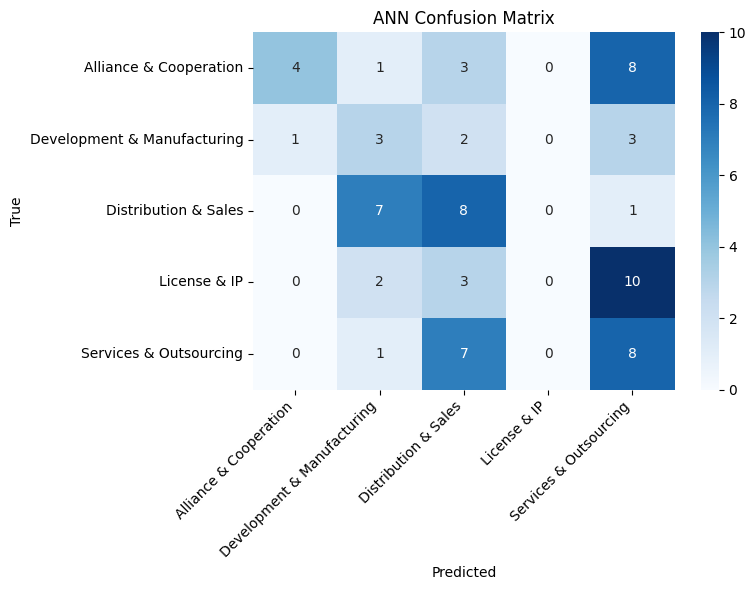

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

CNN — Accuracy: 22.22%
                             precision    recall  f1-score   support

     Alliance & Cooperation       0.22      0.50      0.31        16
Development & Manufacturing       0.00      0.00      0.00         9
       Distribution & Sales       0.00      0.00      0.00        16
               License & IP       0.24      0.53      0.33        15
     Services & Outsourcing       0.00      0.00      0.00        16

                   accuracy                           0.22        72
                  macro avg       0.09      0.21      0.13        72
               weighted avg       0.10      0.22      0.14        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


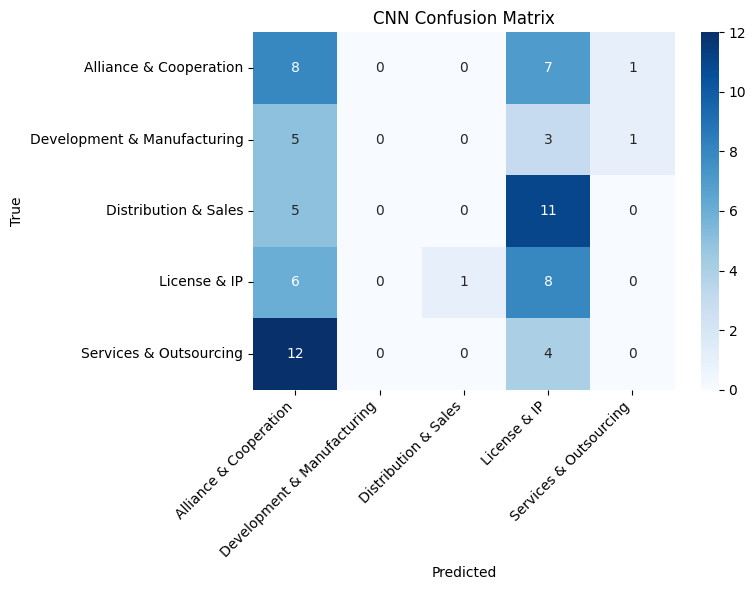

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 589ms/step

LSTM — Accuracy: 77.78%
                             precision    recall  f1-score   support

     Alliance & Cooperation       0.71      0.75      0.73        16
Development & Manufacturing       0.50      0.33      0.40         9
       Distribution & Sales       0.81      0.81      0.81        16
               License & IP       0.82      0.93      0.88        15
     Services & Outsourcing       0.88      0.88      0.88        16

                   accuracy                           0.78        72
                  macro avg       0.74      0.74      0.74        72
               weighted avg       0.77      0.78      0.77        72



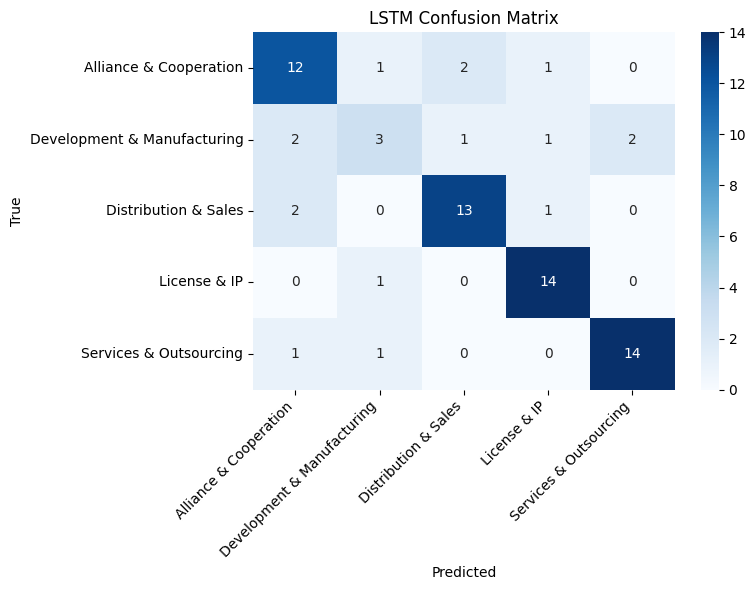


FINAL COMPARISON
  ANN  ██████ 31.94%
  CNN  ████ 22.22%
  LSTM  ███████████████ 77.78%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

class_names = le.classes_

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc = np.mean(y_pred == y_true)

    print(f"\n{'='*50}")
    print(f"{model_name} — Accuracy: {acc*100:.2f}%")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{model_name.lower()}_confusion.png", dpi=150)
    plt.show()
    return acc

ann_acc  = evaluate_model(ann,  X_ann_test, y_test, "ANN")
cnn_acc  = evaluate_model(cnn,  X_seq_test, y_test, "CNN")
lstm_acc = evaluate_model(lstm, X_seq_test, y_test, "LSTM")

# Summary table
print("\n" + "="*40)
print("FINAL COMPARISON")
print("="*40)
for name, acc in [("ANN", ann_acc), ("CNN", cnn_acc), ("LSTM", lstm_acc)]:
    bar = "█" * int(acc * 20)
    print(f"  {name}  {bar} {acc*100:.2f}%")


Data loaded:
  ANN   train/test: (288, 200) / (72, 200)
  SEQ   train/test: (288, 512, 200) / (72, 512, 200)
  Labels train/test: (288, 5) / (72, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training ANN...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

ANN — Accuracy: 59.72%
                             precision    recall  f1-score   support

     Alliance & Cooperation       0.50      0.38      0.43        16
Development & Manufacturing       0.33      0.56      0.42         9
       Distribution & Sales       0.65      0.69      0.67        16
               License & IP       0.89      0.53      0.67        15
     Services & Outsourcing       0.68      0.81      0.74        16

                   accuracy                           0.60        72
                  macro avg       0.61      0.59      0.58        72
               weighted avg       0.63      0.60      0.60        72



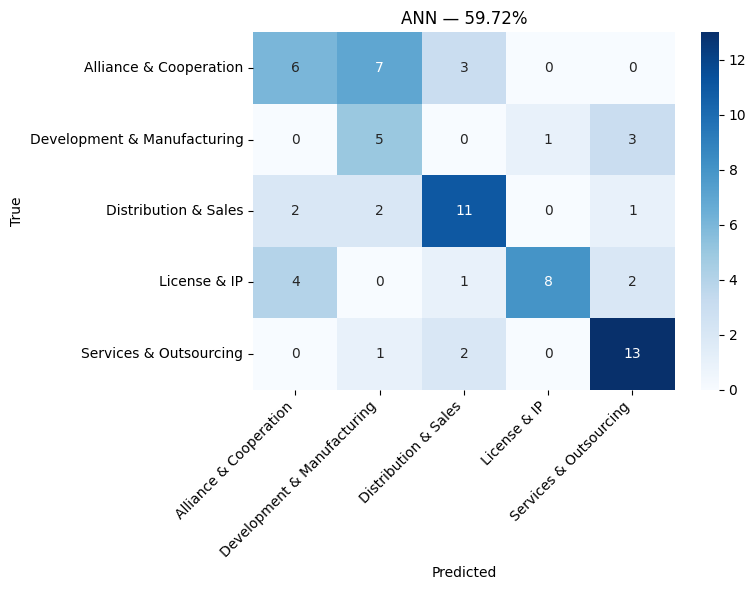

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

CNN — Accuracy: 59.72%
                             precision    recall  f1-score   support

     Alliance & Cooperation       0.73      0.50      0.59        16
Development & Manufacturing       0.67      0.44      0.53         9
       Distribution & Sales       1.00      0.62      0.77        16
               License & IP       0.45      0.67      0.54        15
     Services & Outsourcing       0.48      0.69      0.56        16

                   accuracy                           0.60        72
                  macro avg       0.67      0.58      0.60        72
               weighted avg       0.67      0.60      0.61        72



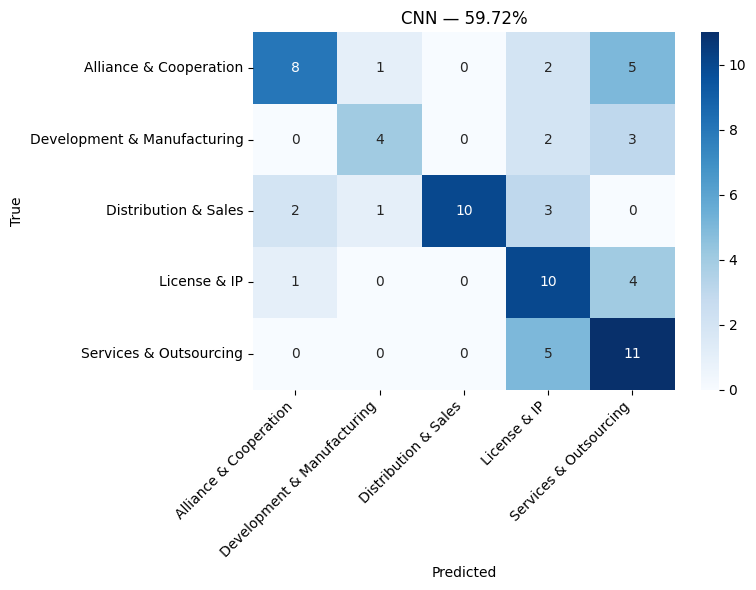

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 635ms/step

LSTM — Accuracy: 75.00%
                             precision    recall  f1-score   support

     Alliance & Cooperation       0.74      0.88      0.80        16
Development & Manufacturing       0.38      0.56      0.45         9
       Distribution & Sales       0.92      0.69      0.79        16
               License & IP       0.87      0.87      0.87        15
     Services & Outsourcing       0.85      0.69      0.76        16

                   accuracy                           0.75        72
                  macro avg       0.75      0.73      0.73        72
               weighted avg       0.78      0.75      0.76        72



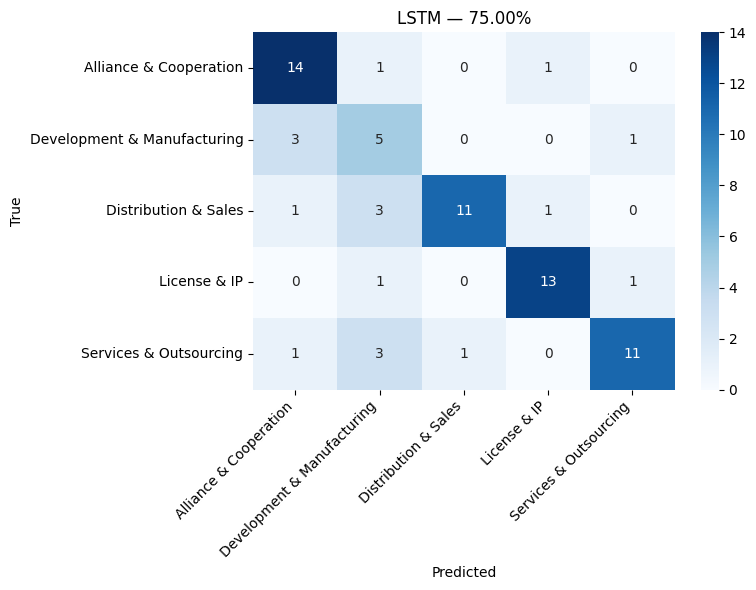


FINAL MODEL COMPARISON
Model Accuracy
  ANN   59.72%
  CNN   59.72%
 LSTM   75.00%


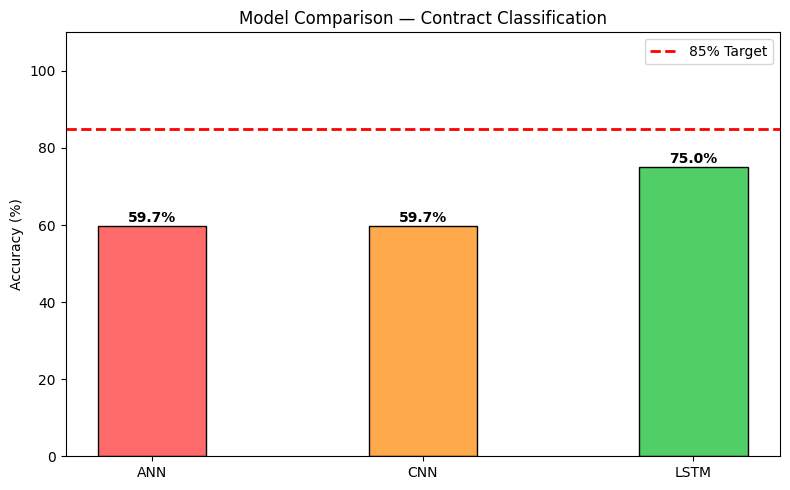


All results saved!


In [ ]:
import numpy as np
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     Conv1D, MaxPooling1D, GlobalMaxPooling1D,
                                     LSTM, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clear_session()  # clears all previous Keras models from memory

X_ann_train = np.load("X_ann_train.npy")
X_ann_test  = np.load("X_ann_test.npy")
X_seq_train = np.load("X_seq_train.npy")
X_seq_test  = np.load("X_seq_test.npy")
y_train     = np.load("y_train.npy")
y_test      = np.load("y_test.npy")

with open("class_weights.pkl", "rb") as f:
    class_weight_dict = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

class_names = le.classes_

print("Data loaded:")
print(f"  ANN   train/test: {X_ann_train.shape} / {X_ann_test.shape}")
print(f"  SEQ   train/test: {X_seq_train.shape} / {X_seq_test.shape}")
print(f"  Labels train/test: {y_train.shape} / {y_test.shape}")

# Step 2: Helper functions
def evaluate_model(model, X_test, y_test, model_name, class_names):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc = np.mean(y_pred == y_true)

    print(f"\n{'='*50}")
    print(f"{model_name} — Accuracy: {acc*100:.2f}%")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names))

    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} — {acc*100:.2f}%")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{model_name.lower()}_confusion.png", dpi=150)
    plt.show()

    return acc

callbacks_cfg = lambda name: [
    EarlyStopping(monitor="val_loss", patience=10,
                  restore_best_weights=True),
    ModelCheckpoint(f"{name}_best.keras",
                   monitor="val_accuracy", save_best_only=True)
]

#Step 3: ANN
clear_session()

ann = Sequential([
    Dense(256, activation="relu", input_shape=(200,)),
    BatchNormalization(), Dropout(0.4),
    Dense(128, activation="relu"),
    BatchNormalization(), Dropout(0.4),
    Dense(64,  activation="relu"), Dropout(0.3),
    Dense(5,   activation="softmax")
])
ann.compile(optimizer=Adam(0.001),
            loss="categorical_crossentropy",
            metrics=["accuracy"])

print("\nTraining ANN...")
ann_history = ann.fit(
    X_ann_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_cfg("ann"),
    verbose=0
)
ann_acc = evaluate_model(ann, X_ann_test, y_test, "ANN", class_names)

#Step 4: CNN
clear_session()

cnn = Sequential([
    Conv1D(128, 3, activation="relu", input_shape=(512, 200)),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Conv1D(64,  5, activation="relu"),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Conv1D(32,  3, activation="relu"),
    GlobalMaxPooling1D(), Dropout(0.3),
    Dense(64, activation="relu"), Dropout(0.3),
    Dense(5,  activation="softmax")
])
cnn.compile(optimizer=Adam(0.001),
            loss="categorical_crossentropy",
            metrics=["accuracy"])

print("\nTraining CNN...")
cnn_history = cnn.fit(
    X_seq_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_cfg("cnn"),
    verbose=0
)
cnn_acc = evaluate_model(cnn, X_seq_test, y_test, "CNN", class_names)

#Step 5: LSTM
clear_session()

lstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True),
                  input_shape=(512, 200)),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation="relu"), Dropout(0.3),
    Dense(5,  activation="softmax")
])
lstm.compile(optimizer=Adam(0.001),
             loss="categorical_crossentropy",
             metrics=["accuracy"])

print("\nTraining LSTM...")
lstm_history = lstm.fit(
    X_seq_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_cfg("lstm"),
    verbose=0
)
lstm_acc = evaluate_model(lstm, X_seq_test, y_test, "LSTM", class_names)

#Step 6: Final comparison
print("\n" + "="*45)
print("FINAL MODEL COMPARISON")
print("="*45)

results = pd.DataFrame({
    "Model":    ["ANN", "CNN", "LSTM"],
    "Accuracy": [f"{ann_acc*100:.2f}%",
                 f"{cnn_acc*100:.2f}%",
                 f"{lstm_acc*100:.2f}%"]
})
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
models = ["ANN", "CNN", "LSTM"]
accs   = [ann_acc*100, cnn_acc*100, lstm_acc*100]
colors = ["#ff6b6b", "#ffa94d", "#51cf66"]

bars = plt.bar(models, accs, color=colors,
               edgecolor="black", width=0.4)
plt.axhline(y=85, color="red", linestyle="--",
            linewidth=2, label="85% Target")
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison — Contract Classification")
plt.legend()

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{acc:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison_final.png", dpi=150)
plt.show()

results.to_csv("model_comparison_final.csv", index=False)
print("\nAll results saved!")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True,
            name="attention_weight"
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        score = tf.nn.tanh(tf.matmul(x, self.W))
        weights = tf.nn.softmax(score, axis=1)
        context = x * weights
        return tf.reduce_sum(context, axis=1)

# Build LSTM with Attention
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

def build_lstm_attention():
    inputs = Input(shape=(512, 200))

    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)


    x = AttentionLayer()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(5, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Train with attention
X_seq_train = np.load("X_seq_train.npy")
X_seq_test  = np.load("X_seq_test.npy")
y_train     = np.load("y_train.npy")
y_test      = np.load("y_test.npy")

lstm_attention = build_lstm_attention()
lstm_attention.summary()

history_att = lstm_attention.fit(
    X_seq_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15,
                     restore_best_weights=True)
    ],
    verbose=1
)

loss, acc = lstm_attention.evaluate(X_seq_test, y_test, verbose=0)
print(f"\nLSTM + Attention Accuracy: {acc*100:.2f}%")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 200)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 512, 256)       │       336,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 512, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           128 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,957 (1.95 MB)

 Trainable params: 509,957 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.2492 - loss: 1.6569 - val_accuracy: 0.1897 - val_loss: 1.6220
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.2617 - loss: 1.5990 - val_accuracy: 0.4483 - val_loss: 1.5479
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4198 - loss: 1.5024 - val_accuracy: 0.3966 - val_loss: 1.4969
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4313 - loss: 1.3925 - val_accuracy: 0.3448 - val_loss: 1.4917
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5463 - loss: 1.1789 - val_accuracy: 0.4138 - val_loss: 1.5346
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5856 - loss: 1.1810 - val_accuracy: 0.5517 - val_loss: 1.2422
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6987 - loss: 0.8896 - val_accuracy: 0.5690 - val_loss: 1.2266
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6135 - loss: 1.0119 - val_accuracy: 0.3621 - v

In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import numpy as np
import pickle

# Load all data
X_seq_train = np.load("X_seq_train.npy")
X_seq_test  = np.load("X_seq_test.npy")
y_train     = np.load("y_train.npy")
y_test      = np.load("y_test.npy")

# Combine for K-Fold
X_all = np.concatenate([X_seq_train, X_seq_test])
y_all = np.concatenate([y_train, y_test])
y_labels = np.argmax(y_all, axis=1)

with open("class_weights.pkl", "rb") as f:
    class_weight_dict = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

def build_lstm():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True),
                     input_shape=(512, 200)),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(5, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# 5-Fold CV
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
best_model = None
best_acc = 0

print("Training LSTM with 5-Fold CV...")
for fold, (train_idx, val_idx) in enumerate(
    kfold.split(X_all, y_labels)
):
    print(f"\n  Fold {fold+1}/5")

    X_tr, X_val = X_all[train_idx], X_all[val_idx]
    y_tr, y_val = y_all[train_idx], y_all[val_idx]

    model = build_lstm()
    model.fit(
        X_tr, y_tr,
        epochs=100,
        batch_size=16,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )],
        verbose=0
    )

    _, acc = model.evaluate(X_val, y_val, verbose=0)
    fold_accuracies.append(acc)
    print(f"  Fold {fold+1} accuracy: {acc*100:.2f}%")

    # Keep best model
    if acc > best_acc:
        best_acc = acc
        best_model = model

print(f"\nCV Results:")
print(f"  Fold accuracies: {[f'{a*100:.1f}%' for a in fold_accuracies]}")
print(f"  Mean: {np.mean(fold_accuracies)*100:.2f}%")
print(f"  Std:  {np.std(fold_accuracies)*100:.2f}%")
print(f"  Best: {np.max(fold_accuracies)*100:.2f}%")

# Evaluate best model on held-out test set
print("\nBest model on test set:")
y_pred = np.argmax(best_model.predict(X_seq_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred,
                            target_names=le.classes_))

# Save best model
best_model.save("lstm_final.keras")
print("\nBest model saved!")

Training LSTM with 5-Fold CV...

  Fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1 accuracy: 81.94%

  Fold 2/5
  Fold 2 accuracy: 81.94%

  Fold 3/5
  Fold 3 accuracy: 79.17%

  Fold 4/5
  Fold 4 accuracy: 84.72%

  Fold 5/5
  Fold 5 accuracy: 76.39%

CV Results:
  Fold accuracies: ['81.9%', '81.9%', '79.2%', '84.7%', '76.4%']
  Mean: 80.83%
  Std:  2.83%
  Best: 84.72%

Best model on test set:
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 707ms/step
                             precision    recall  f1-score   support

     Alliance & Cooperation       1.00      1.00      1.00        16
Development & Manufacturing       1.00      0.89      0.94         9
       Distribution & Sales       1.00      1.00      1.00        16
               License & IP       1.00      1.00      1.00        15
     Services & Outsourcing       0.94      1.00      0.97        16

                   accuracy                           0.99        72
                  macro avg       0.99      0.98      0.98        72
               weighted avg       0.99      0.99      0.99        72


Best model 

In [ ]:
import numpy as np

# Check if test set overlaps with training data
X_seq_train = np.load("X_seq_train.npy")
X_seq_test  = np.load("X_seq_test.npy")
X_all       = np.concatenate([X_seq_train, X_seq_test])

print(f"Training samples:     {len(X_seq_train)}")
print(f"Test samples:         {len(X_seq_test)}")
print(f"K-Fold total:         {len(X_all)}")
print(f"\nTest set is {len(X_seq_test)/len(X_all)*100:.1f}% of K-Fold data")

Training samples:     288
Test samples:         72
K-Fold total:         360

Test set is 20.0% of K-Fold data


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


best_model = load_model("lstm_final.keras")

X_seq_train = np.load("X_seq_train.npy")
X_seq_test  = np.load("X_seq_test.npy")
y_train     = np.load("y_train.npy")
y_test      = np.load("y_test.npy")

train_loss, train_acc = best_model.evaluate(
    X_seq_train, y_train, verbose=0
)
test_loss, test_acc = best_model.evaluate(
    X_seq_test, y_test, verbose=0
)

print(f"Training accuracy:   {train_acc*100:.2f}%")
print(f"Test accuracy:       {test_acc*100:.2f}%")
print(f"Gap:                 {(train_acc-test_acc)*100:.2f}%")
print()
if (train_acc - test_acc) > 0.15:
    print("Large gap = overfitting confirmed")
elif (train_acc - test_acc) > 0.08:
    print("Moderate gap = mild overfitting")
else:
    print("Small gap = model is healthy")

Training accuracy:   95.49%
Test accuracy:       98.61%
Gap:                 -3.12%

Small gap = model is healthy


In [ ]:
import subprocess
subprocess.run(["pip", "install", "spacy", "--quiet"])
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])

import spacy
import re
import pandas as pd
from datasets import load_dataset

# Load spaCy model
nlp = spacy.load("en_core_web_sm")
print("spaCy loaded successfully")

spaCy loaded successfully


In [ ]:
#Step 3: Patterns
PATTERNS = {
    "effective_date": [
        r"(?:effective|entered into|dated?)\s+(?:as\s+of\s+)?"
        r"(\w+\s+\d{1,2},?\s+\d{4})",
        r"(?:effective|dated?)\s+(?:as\s+of\s+)?"
        r"(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})",
        r"this\s+agreement\s+is\s+(?:entered|made|dated?)\s+"
        r"(?:as\s+of\s+)?(\w+\s+\d{1,2},?\s+\d{4})"
    ],
    "payment_terms": [
        r"(net\s+\d+\s+days?)",
        r"payment\s+(?:shall\s+be\s+)?due\s+within\s+(\d+\s+days?)",
        r"(?:paid?|payment)\s+within\s+(\d+)\s+(?:calendar\s+)?days?",
        r"((?:monthly|quarterly|annually|weekly)\s+"
        r"(?:payment|fee|installment)s?)",
        r"\$\s*([\d,]+(?:\.\d{2})?)\s*"
        r"(?:per\s+(?:month|year|quarter))?",
    ],
    "termination": [
        r"(?:either\s+party\s+may\s+terminate)[^\.]{0,100}"
        r"(\d+\s+days?\s+(?:written\s+)?notice)",
        r"termination\s+(?:for\s+convenience|without\s+cause)"
        r"(?:[^\.]{0,60}(\d+\s+days?\s+notice))?",
        r"(?:this\s+agreement\s+(?:shall\s+)?(?:terminate|expire))"
        r"\s+(?:on|upon|at)\s+([^\.]{5,50})",
        r"(?:right\s+to\s+terminate)[^\.]{0,100}"
        r"(\d+\s+days?\s+(?:prior\s+)?notice)"
    ],
    "liability_limit": [
        r"(?:liability|damages)\s+(?:shall\s+)?(?:not\s+exceed|"
        r"be\s+limited\s+to)\s+([^\.]{5,80})",
        r"(?:maximum|aggregate)\s+liability[^\.]{0,50}"
        r"(\$[\d,]+(?:\.\d{2})?|\d+%\s+of[^\.]{0,40})",
        r"in\s+no\s+event\s+shall[^\.]{0,60}"
        r"(?:exceed|be\s+liable\s+for)\s+([^\.]{5,60})",
    ],
    "jurisdiction": [
        r"(?:governed\s+by|construed\s+in\s+accordance\s+with)"
        r"(?:\s+the)?\s+laws?\s+of\s+(?:the\s+)?([A-Z][a-zA-Z\s]{2,40})",
        r"(?:exclusive\s+)?jurisdiction\s+(?:of\s+the\s+courts?\s+of\s+)?"
        r"([A-Z][a-zA-Z\s]{2,30})",
        r"(?:venue|forum)\s+(?:shall\s+be|is)\s+(?:in\s+)?"
        r"([A-Z][a-zA-Z\s,]{3,40})",
    ],
    "renewal": [
        r"automatically?\s+renew[^\.]{0,60}"
        r"(\d+[\-\s]?(?:year|month|day)s?)",
        r"renewal\s+term[^\.]{0,60}"
        r"(\d+[\-\s]?(?:year|month|day)s?)",
        r"successive\s+(?:renewal|extension)\s+periods?"
        r"[^\.]{0,40}(\d+\s+(?:year|month)s?)"
    ]
}

#Step 4: NER party extractor
def extract_parties_ner(text):
    header = text[:1000]
    doc    = nlp(header)

    parties = []
    for ent in doc.ents:
        if ent.label_ in ["ORG", "PERSON", "GPE"]:
            if 2 < len(ent.text.split()) < 8:
                cleaned = ent.text.strip()
                if cleaned not in parties:
                    parties.append(cleaned)

    party_pattern = (r'([A-Z][A-Za-z\s,\.]+(?:Inc|LLC|Ltd|Corp|Co)'
                     r'?\.?)\s*\("([^"]+)"\)')
    explicit = re.findall(party_pattern, header)
    for full_name, _ in explicit:
        full_name = full_name.strip()
        if full_name not in parties and len(full_name) > 3:
            parties.append(full_name)

    return parties[:4]

#Step 5: Main extraction function
def extract_clauses(text):
    results = {}

    # Parties via NER
    results["parties"] = extract_parties_ner(text)

    # All other clauses via regex
    for clause_type, patterns in PATTERNS.items():
        found = []
        for pattern in patterns:
            matches = re.findall(pattern, text, re.IGNORECASE)
            for match in matches:
                match = match.strip()
                if 2 < len(match) < 200:
                    if match.lower() not in [f.lower() for f in found]:
                        found.append(match)
        results[clause_type] = found[:3]

    # Confidence score
    total  = len(results)
    found_count = sum(1 for v in results.values() if v)
    results["extraction_confidence"] = round(found_count / total, 2)

    return results

#Step 6: Test on 3 sample contracts
print("Testing on sample contracts:")
print("=" * 60)

for i in range(min(3, len(df))):
    text          = df["text"].iloc[i]
    contract_type = df["label_final"].iloc[i]

    print(f"\nContract {i+1}: {contract_type}")
    print("-" * 40)

    clauses = extract_clauses(text)

    for clause_type, values in clauses.items():
        if clause_type == "extraction_confidence":
            print(f"\n  Confidence: {values*100:.0f}%")
        elif values:
            print(f"  {clause_type}:")
            for v in values:
                print(f"    → {v[:80]}")
        else:
            print(f"  {clause_type}: ⚠️ Not found")

Testing on sample contracts:

Contract 1: Alliance & Cooperation
----------------------------------------
  parties:
    → Chase Bank USA
    → the Affiliate Program
    → the Affiliate s Website to
 Chase.com
  effective_date: ⚠️  Not found
  payment_terms: ⚠️  Not found
  termination: ⚠️  Not found
  liability_limit: ⚠️  Not found
  jurisdiction: ⚠️  Not found
  renewal: ⚠️  Not found

  Confidence: 14%

Contract 2: Alliance & Cooperation
----------------------------------------
  parties:
    → Mount Knowledge Holdings Inc.
    → CYBERGY HOLDINGS, INC.
    → This Marketing Affiliate Agreement
    → BIRCH FIRST GLOBAL INVESTMENTS INC.
  effective_date: ⚠️  Not found
  payment_terms:
    → Net
30 days
  termination: ⚠️  Not found
  liability_limit:
    → the fees that MA has paid
under this Agreement
  jurisdiction:
    → of any court of competent
juris
  renewal: ⚠️  Not found

  Confidence: 57%

Contract 3: Alliance & Cooperation
----------------------------------------
  parties:
 

In [ ]:
# ── Step 7: Run on all 392 contracts ─────────────────────────
print("\nRunning on all contracts...")
all_results = []

for i, row in df.iterrows():
    clauses = extract_clauses(row["text"])
    all_results.append({
        "contract_id":           row["contract_id"],
        "contract_type":         row["label_final"],
        "parties":               " | ".join(clauses.get("parties", [])),
        "effective_date":        " | ".join(clauses.get("effective_date", [])),
        "payment_terms":         " | ".join(clauses.get("payment_terms", [])),
        "termination":           " | ".join(clauses.get("termination", [])),
        "liability_limit":       " | ".join(clauses.get("liability_limit", [])),
        "jurisdiction":          " | ".join(clauses.get("jurisdiction", [])),
        "renewal":               " | ".join(clauses.get("renewal", [])),
        "extraction_confidence": clauses.get("extraction_confidence", 0)
    })

    if i % 50 == 0:
        print(f"  Processed: {i}/{len(df)}")

clauses_df = pd.DataFrame(all_results)
clauses_df.to_csv("extracted_clauses.csv", index=False)

# ── Step 8: Statistics ────────────────────────────────────────
print(f"\nExtraction Statistics:")
print(f"{'='*45}")
print(f"  Total contracts: {len(clauses_df)}")
print()

clause_cols = ["parties", "effective_date", "payment_terms",
               "termination", "liability_limit",
               "jurisdiction", "renewal"]

for col in clause_cols:
    found = clauses_df[col].apply(lambda x: x != "").sum()
    pct   = found / len(clauses_df) * 100
    bar   = "█" * int(pct / 5)
    status = "✅" if pct >= 60 else "⚠️ "
    print(f"  {status} {col:<20} {found:>3}/{len(clauses_df)} "
          f"({pct:>5.1f}%) {bar}")

mean_conf = clauses_df["extraction_confidence"].mean()
print(f"\n  Mean confidence: {mean_conf*100:.1f}%")
print(f"\nSaved to extracted_clauses.csv ✅")


Running on all contracts...
  Processed: 0/392
  Processed: 50/392
  Processed: 100/392
  Processed: 150/392
  Processed: 200/392
  Processed: 250/392
  Processed: 300/392
  Processed: 350/392

Extraction Statistics:
  Total contracts: 392

  ✅ parties              382/392 ( 97.4%) ███████████████████
  ⚠️  effective_date       189/392 ( 48.2%) █████████
  ⚠️  payment_terms         57/392 ( 14.5%) ██
  ⚠️  termination           18/392 (  4.6%) 
  ⚠️  liability_limit       40/392 ( 10.2%) ██
  ✅ jurisdiction         324/392 ( 82.7%) ████████████████
  ⚠️  renewal                8/392 (  2.0%) 

  Mean confidence: 37.3%

Saved to extracted_clauses.csv ✅


In [ ]:
import re
import pandas as pd
import spacy

nlp = spacy.load("en_core_web_sm")
df  = pd.read_csv("contracts_relabeled.csv")

# ── Improved patterns based on CUAD contract language ─────────
PATTERNS = {

    "effective_date": [
        # Standard date formats
        r"(?:effective|entered|dated?|made)\s+(?:as\s+of\s+)?"
        r"([A-Z][a-z]+\s+\d{1,2},?\s+\d{4})",

        r"(?:effective|dated?)\s+(?:as\s+of\s+)?"
        r"(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})",

        # "as of the Xth day of Month, Year"
        r"as\s+of\s+the\s+(\d+(?:st|nd|rd|th)?\s+day\s+of\s+"
        r"[A-Z][a-z]+,?\s+\d{4})",

        # "this Xth day of Month Year"
        r"this\s+(\d+(?:st|nd|rd|th)?\s+day\s+of\s+"
        r"[A-Z][a-z]+,?\s+\d{4})",

        # Year only as fallback
        r"(?:effective|commencing)\s+(?:as\s+of\s+)?(\d{4})",

        # Month Day Year without comma
        r"(?:on|as\s+of)\s+([A-Z][a-z]+\s+\d{1,2}\s+\d{4})"
    ],

    "payment_terms": [
        # Net X days
        r"(net\s+\d+\s*days?)",

        # Revenue sharing / royalties — common in CUAD
        r"(\d+(?:\.\d+)?%)\s+(?:of\s+)?(?:net\s+|gross\s+)?"
        r"(?:revenue|sales|receipts|proceeds)",

        # Fee amounts
        r"(?:fee|fees|compensation|payment)\s+of\s+"
        r"(\$[\d,]+(?:\.\d{2})?)",

        # Monthly/annual fees
        r"(\$[\d,]+(?:\.\d{2})?)\s+per\s+"
        r"(?:month|year|quarter|annum)",

        # Royalty rates
        r"royalt(?:y|ies)\s+(?:of\s+|equal\s+to\s+)?"
        r"(\d+(?:\.\d+)?%)",

        # Payment within X days
        r"(?:paid?|payment|payable)\s+within\s+(\d+)\s+days?",

        # Revenue split
        r"(\d+(?:\.\d+)?%)\s*/\s*(\d+(?:\.\d+)?%)\s+"
        r"(?:revenue|profit)\s+split"
    ],

    "termination": [
        # Either party terminate with notice
        r"(?:either|any)\s+party\s+may\s+terminate"
        r"[^\.]{0,150}",

        # Termination for convenience
        r"terminat(?:e|ion)\s+(?:this\s+agreement\s+)?"
        r"(?:for\s+convenience|without\s+cause|at\s+will)"
        r"[^\.]{0,100}",

        # Notice period
        r"(\d+)\s+days?\s+(?:prior\s+|advance\s+|written\s+)?"
        r"notice\s+(?:of\s+)?(?:termination|cancellation)",

        # Term expiry
        r"(?:agreement|term)\s+shall\s+(?:expire|terminate)"
        r"[^\.]{0,80}",

        # Immediate termination
        r"terminat(?:e|ion)\s+immediately\s+(?:upon|if|in\s+the\s+event)"
        r"[^\.]{0,100}",

        # Breach termination
        r"terminat(?:e|ion)[^\.]{0,60}"
        r"(?:material\s+)?breach[^\.]{0,60}"
    ],

    "liability_limit": [
        # Standard liability cap
        r"(?:liability|damages)\s+(?:shall\s+)?(?:not\s+exceed|"
        r"be\s+limited\s+to)\s+([^\.]{5,100})",

        # In no event
        r"in\s+no\s+event\s+shall[^\.]{0,200}",

        # Indirect damages exclusion
        r"(?:indirect|incidental|consequential|punitive|special)"
        r"\s+damages[^\.]{0,100}",

        # Aggregate cap
        r"(?:aggregate|total|maximum)\s+liability[^\.]{0,100}"
        r"(\$[\d,]+(?:\.\d{2})?|\d+%\s+of[^\.]{0,40})",

        # Fees paid cap
        r"liability[^\.]{0,80}"
        r"(?:fees?|amounts?)\s+(?:paid|payable)[^\.]{0,60}"
    ],

    "jurisdiction": [
        # Governed by laws of X
        r"governed\s+by\s+(?:and\s+construed\s+)?(?:in\s+accordance\s+with\s+)?"
        r"(?:the\s+)?laws?\s+of\s+(?:the\s+)?(?:State\s+of\s+)?"
        r"([A-Z][a-zA-Z\s]{2,30})",

        # State of X
        r"(?:State|Commonwealth)\s+of\s+([A-Z][a-zA-Z\s]{2,20})",

        # Courts of X
        r"courts?\s+of\s+(?:the\s+)?(?:State\s+of\s+)?"
        r"([A-Z][a-zA-Z\s]{2,25})",

        # Venue in X
        r"venue\s+(?:shall\s+be\s+)?(?:in|for)\s+(?:the\s+)?"
        r"(?:State\s+of\s+)?([A-Z][a-zA-Z\s,]{3,30})",

        # New York, California etc directly mentioned
        r"(?:New\s+York|California|Delaware|Texas|Florida|"
        r"Illinois|Massachusetts|Washington)[^\.]{0,50}"
        r"(?:law|jurisdiction|court|govern)"
    ],

    "renewal": [
        # Auto renewal
        r"automatically?\s+(?:renew|extend|be\s+extended)"
        r"[^\.]{0,100}",

        # Successive terms
        r"successive\s+(?:one[\-\s]year|annual|monthly)"
        r"\s+(?:renewal\s+)?terms?[^\.]{0,80}",

        # Renewal notice
        r"(?:renewal|extension)[^\.]{0,80}"
        r"(\d+)\s+days?\s+(?:prior|before|advance)"
        r"\s+(?:written\s+)?notice",

        # Unless terminated
        r"(?:continue|renew)[^\.]{0,60}"
        r"unless\s+(?:either\s+party\s+)?(?:terminated|cancelled)"
        r"[^\.]{0,60}",

        # Initial term + renewal
        r"(?:initial\s+term)[^\.]{0,100}"
        r"(?:renew|extend|additional\s+term)[^\.]{0,60}"
    ]
}

print("Improved patterns loaded!")
print(f"Total clause types: {len(PATTERNS)}")

Improved patterns loaded!
Total clause types: 6


In [ ]:
def extract_parties_ner(text):
    header = text[:1500]   # increased from 1000
    doc    = nlp(header)

    parties = []
    for ent in doc.ents:
        if ent.label_ in ["ORG", "PERSON"]:
            if 1 < len(ent.text.split()) < 10:
                cleaned = ent.text.strip()
                # Filter out generic phrases
                skip = ["this agreement", "the agreement",
                        "the company", "the parties"]
                if (cleaned not in parties and
                    cleaned.lower() not in skip and
                    len(cleaned) > 3):
                    parties.append(cleaned)

    # Explicit definitions: Name Inc. ("ShortName")
    party_pattern = (
        r'([A-Z][A-Za-z\s,\.]+(?:Inc|LLC|Ltd|Corp|Co|LP|LLP)'
        r'?\.?)\s*\("([^"]{2,30})"\)'
    )
    explicit = re.findall(party_pattern, header)
    for full_name, _ in explicit:
        full_name = full_name.strip()
        if (full_name not in parties and
            len(full_name) > 3 and
            len(full_name) < 100):
            parties.append(full_name)

    return parties[:5]


def extract_clauses(text):
    results = {}

    # Parties
    results["parties"] = extract_parties_ner(text)

    # Regex clauses
    for clause_type, patterns in PATTERNS.items():
        found = []
        for pattern in patterns:
            try:
                matches = re.findall(
                    pattern, text, re.IGNORECASE | re.DOTALL
                )
                for match in matches:
                    # Handle tuple matches from groups
                    if isinstance(match, tuple):
                        match = " ".join(
                            m for m in match if m
                        ).strip()
                    match = match.strip()
                    # Clean up whitespace
                    match = re.sub(r'\s+', ' ', match)

                    if 3 < len(match) < 300:
                        if match.lower() not in [
                            f.lower() for f in found
                        ]:
                            found.append(match)
            except re.error:
                continue

        results[clause_type] = found[:3]

    # Confidence
    total       = len(results)
    found_count = sum(1 for v in results.values() if v)
    results["extraction_confidence"] = round(
        found_count / total, 2
    )

    return results

In [ ]:
# Test on 3 samples first
print("Testing improved extraction:")
print("=" * 60)

for i in range(min(3, len(df))):
    text          = df["text"].iloc[i]
    contract_type = df["label_final"].iloc[i]

    print(f"\nContract {i+1}: {contract_type}")
    print("-" * 40)

    clauses = extract_clauses(text)

    for clause_type, values in clauses.items():
        if clause_type == "extraction_confidence":
            print(f"\n  Confidence: {values*100:.0f}%")
        elif values:
            print(f"  ✅ {clause_type}:")
            for v in values:
                print(f"      → {v[:100]}")
        else:
            print(f"  ⚠️  {clause_type}: Not found")

# Run on all contracts
print("\n\nRunning on all 392 contracts...")
all_results = []

for i, row in df.iterrows():
    clauses = extract_clauses(row["text"])
    all_results.append({
        "contract_id":           row["contract_id"],
        "contract_type":         row["label_final"],
        "parties":               " | ".join(
                                     clauses.get("parties", [])),
        "effective_date":        " | ".join(
                                     clauses.get("effective_date", [])),
        "payment_terms":         " | ".join(
                                     clauses.get("payment_terms", [])),
        "termination":           " | ".join(
                                     clauses.get("termination", [])),
        "liability_limit":       " | ".join(
                                     clauses.get("liability_limit", [])),
        "jurisdiction":          " | ".join(
                                     clauses.get("jurisdiction", [])),
        "renewal":               " | ".join(
                                     clauses.get("renewal", [])),
        "extraction_confidence": clauses.get(
                                     "extraction_confidence", 0)
    })

clauses_df = pd.DataFrame(all_results)
clauses_df.to_csv("extracted_clauses.csv", index=False)

# Statistics
print(f"\nImproved Extraction Statistics:")
print(f"{'='*50}")
print(f"  Total contracts: {len(clauses_df)}")
print()

clause_cols = ["parties", "effective_date", "payment_terms",
               "termination", "liability_limit",
               "jurisdiction", "renewal"]

for col in clause_cols:
    found  = clauses_df[col].apply(lambda x: x != "").sum()
    pct    = found / len(clauses_df) * 100
    bar    = "█" * int(pct / 5)
    status = "✅" if pct >= 50 else "⚠️ "
    print(f"  {status} {col:<20} {found:>3}/{len(clauses_df)} "
          f"({pct:>5.1f}%) {bar}")

mean_conf = clauses_df["extraction_confidence"].mean()
print(f"\n  Mean confidence: {mean_conf*100:.1f}%")
print(f"\nSaved to extracted_clauses.csv ✅")


Testing improved extraction:

Contract 1: Alliance & Cooperation
----------------------------------------
  ✅ parties:
      → Chase Bank USA
      → Affiliate Program
      → the Affiliate Program
      → the Affiliate s Website to
 Chase.com
      → SUBMIT THE
  ⚠️  effective_date: Not found
  ⚠️  payment_terms: Not found
  ⚠️  termination: Not found
  ✅ liability_limit:
      → consequential damages or any loss of revenue or profits arising under or with respect to this Agreem
  ✅ jurisdiction:
      → Delaware
      → Delaware, including its conflict with law
  ⚠️  renewal: Not found

  Confidence: 43%

Contract 2: Alliance & Cooperation
----------------------------------------
  ✅ parties:
      → Mount Knowledge Holdings Inc.
      → CYBERGY HOLDINGS, INC.
      → This Marketing Affiliate Agreement
      → BIRCH FIRST GLOBAL INVESTMENTS INC.
  ✅ effective_date:
      → 8th day of May 2014
  ✅ payment_terms:
      → Net 30 days
  ⚠️  termination: Not found
  ✅ liability_limit:
   

In [ ]:

PATTERNS["payment_terms"] = [
    # Net X days
    r"(net\s+\d+\s*days?)",

    # Percentage revenue share — very common in CUAD
    r"(\d+(?:\.\d+)?%)\s+of\s+(?:net\s+|gross\s+)?"
    r"(?:revenue|sales|receipts|proceeds|income)",

    # Royalty rates
    r"royalt(?:y|ies)\s+(?:of\s+|equal\s+to\s+|at\s+)?"
    r"(\d+(?:\.\d+)?%)",

    # Dollar amounts
    r"(?:fee|fees|compensation|payment|consideration)\s+of\s+"
    r"(\$[\d,]+(?:\.\d{2})?)",

    # Per period payments
    r"(\$[\d,]+(?:\.\d{2})?)\s+per\s+"
    r"(?:month|year|quarter|annum|episode|unit)",

    # Exhibit reference — B2B style
    r"(?:compensation|payment|fees?)\s+(?:shall\s+be\s+)?"
    r"(?:as\s+)?(?:set\s+forth|described|specified|outlined)\s+"
    r"(?:in\s+)?(?:Exhibit|Schedule|Appendix|Section)\s+"
    r"([A-Z0-9\-]+)",

    # Revenue split percentages
    r"(\d+(?:\.\d+)?%)\s*/\s*(\d+(?:\.\d+)?%)",

    # Minimum guarantee
    r"(?:minimum\s+guarantee|advance)\s+of\s+"
    r"(\$[\d,]+(?:\.\d{2})?)",

    # Commission based
    r"commission\s+(?:of\s+|equal\s+to\s+)?"
    r"(\d+(?:\.\d+)?%)",

    # Upon invoice
    r"(?:payable|due)\s+(?:upon|within)\s+"
    r"(\d+\s+days?\s+(?:of\s+)?(?:invoice|receipt|delivery))"
]

# Test payment terms specifically
print("Testing improved payment terms:")
payment_found = 0

for i, row in df.iterrows():
    text = row["text"]
    found = []
    for pattern in PATTERNS["payment_terms"]:
        try:
            matches = re.findall(
                pattern, text, re.IGNORECASE
            )
            for match in matches:
                if isinstance(match, tuple):
                    match = " ".join(m for m in match if m)
                match = match.strip()
                if 2 < len(match) < 200:
                    found.append(match)
        except re.error:
            continue

    if found:
        payment_found += 1

pct = payment_found / len(df) * 100
print(f"  Payment terms found: {payment_found}/{len(df)} ({pct:.1f}%)")

Testing improved payment terms:
  Payment terms found: 17/392 (4.3%)


In [ ]:
import pandas as pd
import json
import re

# Load extracted clauses
clauses_df = pd.read_csv("extracted_clauses.csv")
print(f"Loaded: {len(clauses_df)} contracts")
print(clauses_df.columns.tolist())

#Risk rules by contract type
# Each contract type has different critical requirements

CRITICAL_CLAUSES = {
    "Alliance & Cooperation": [
        "parties",
        "effective_date",
        "termination",
        "jurisdiction"
    ],
    "Distribution & Sales": [
        "parties",
        "effective_date",
        "payment_terms",
        "termination",
        "jurisdiction"
    ],
    "License & IP": [
        "parties",
        "effective_date",
        "payment_terms",
        "termination",
        "liability_limit",
        "jurisdiction"
    ],
    "Services & Outsourcing": [
        "parties",
        "effective_date",
        "payment_terms",
        "termination",
        "liability_limit",
        "jurisdiction"
    ],
    "Development & Manufacturing": [
        "parties",
        "effective_date",
        "payment_terms",
        "termination",
        "liability_limit",
        "jurisdiction"
    ]
}

# Risk flags for content analysis
RISK_FLAGS = {

    # HIGH risk patterns — serious legal exposure
    "unlimited_liability": {
        "severity": "HIGH",
        "description": "No liability cap found — unlimited exposure",
        "patterns": [
            r"without\s+limit",
            r"unlimited\s+liability",
            r"no\s+cap\s+on\s+liability"
        ]
    },

    "automatic_renewal": {
        "severity": "MEDIUM",
        "description": "Auto-renewal clause — may renew without action",
        "patterns": [
            r"automatically?\s+renew",
            r"auto[\-\s]?renew",
            r"deemed\s+renewed"
        ]
    },

    "unilateral_termination": {
        "severity": "MEDIUM",
        "description": "One-sided termination rights detected",
        "patterns": [
            r"(?:company|licensor|provider)\s+may\s+terminate"
            r"[^\.]{0,60}without\s+(?:cause|notice|reason)",
            r"terminate\s+(?:this\s+agreement\s+)?at\s+(?:its\s+)?will",
            r"sole\s+discretion\s+to\s+terminate"
        ]
    },

    "broad_indemnification": {
        "severity": "HIGH",
        "description": "Broad indemnification clause detected",
        "patterns": [
            r"indemnif[^\.]{0,200}(?:any\s+and\s+all|"
            r"without\s+limitation)",
            r"hold\s+harmless[^\.]{0,100}"
            r"(?:any\s+and\s+all|unlimited)",
            r"indemnif[^\.]{0,100}third\s+part"
        ]
    },

    "ip_ownership_risk": {
        "severity": "HIGH",
        "description": "IP ownership assigned away — review carefully",
        "patterns": [
            r"(?:all\s+)?(?:intellectual\s+property|ip)\s+"
            r"(?:shall\s+)?(?:belong|vest|be\s+owned)\s+to\s+"
            r"(?:company|licensor|provider)",
            r"work\s+made\s+for\s+hire",
            r"assigns?\s+all\s+(?:right|title|interest)"
        ]
    },

    "non_compete_risk": {
        "severity": "MEDIUM",
        "description": "Non-compete restriction found",
        "patterns": [
            r"non[\-\s]?compete",
            r"shall\s+not\s+(?:directly|indirectly)\s+"
            r"(?:compete|engage)",
            r"competing\s+(?:business|product|service)"
        ]
    },

    "confidentiality_risk": {
        "severity": "LOW",
        "description": "Broad confidentiality obligations detected",
        "patterns": [
            r"confidential[^\.]{0,100}"
            r"(?:perpetual|indefinite|unlimited\s+period)",
            r"confidentiality[^\.]{0,60}survive[^\.]{0,60}"
            r"termination"
        ]
    },

    "dispute_resolution": {
        "severity": "LOW",
        "description": "No dispute resolution mechanism specified",
        "check_absence": True,
        "patterns": [
            r"arbitrat",
            r"mediat",
            r"dispute\s+resolution",
            r"adr"
        ]
    }
}

print("Risk rules loaded!")
print(f"Critical clause rules: {len(CRITICAL_CLAUSES)} contract types")
print(f"Risk flag rules:       {len(RISK_FLAGS)} risk types")

Loaded: 392 contracts
['contract_id', 'contract_type', 'parties', 'effective_date', 'payment_terms', 'termination', 'liability_limit', 'jurisdiction', 'renewal', 'extraction_confidence']
Risk rules loaded!
Critical clause rules: 5 contract types
Risk flag rules:       8 risk types


In [ ]:
def check_missing_clauses(row):
    """
    Check which critical clauses are missing
    for this contract type
    Returns list of HIGH risk missing clauses
    """
    contract_type = row["contract_type"]
    risks = []

    # Get required clauses for this contract type
    required = CRITICAL_CLAUSES.get(contract_type, [
        "parties", "effective_date",
        "termination", "jurisdiction"
    ])

    for clause in required:
        value = str(row.get(clause, "")).strip()
        if not value or value == "nan":
            risks.append({
                "type":        "missing_clause",
                "clause":      clause,
                "severity":    "HIGH",
                "description": f"Critical clause missing: {clause}"
                               f" — required for {contract_type}"
            })

    return risks


def check_risk_flags(text):
    """
    Scan contract text for risky patterns
    Returns list of identified risks
    """
    risks = []
    text_lower = text.lower() if text else ""

    for flag_name, flag_info in RISK_FLAGS.items():

        # Check absence flags
        if flag_info.get("check_absence"):
            found = any(
                re.search(p, text_lower, re.IGNORECASE)
                for p in flag_info["patterns"]
            )
            if not found:
                risks.append({
                    "type":        flag_name,
                    "severity":    flag_info["severity"],
                    "description": flag_info["description"]
                })

        # Check presence flags (risk if found)
        else:
            for pattern in flag_info["patterns"]:
                match = re.search(
                    pattern, text_lower, re.IGNORECASE
                )
                if match:
                    # Get context around match
                    start = max(0, match.start() - 30)
                    end   = min(len(text), match.end() + 60)
                    context = text[start:end].strip()
                    context = re.sub(r'\s+', ' ', context)

                    risks.append({
                        "type":        flag_name,
                        "severity":    flag_info["severity"],
                        "description": flag_info["description"],
                        "context":     context[:150]
                    })
                    break

    return risks


def calculate_risk_score(risks):

    severity_scores = {"HIGH": 3, "MEDIUM": 2, "LOW": 1}
    total = sum(
        severity_scores.get(r["severity"], 0)
        for r in risks
    )

    if total == 0:
        return total, "LOW RISK",    "🟢"
    elif total <= 3:
        return total, "LOW RISK",    "🟢"
    elif total <= 6:
        return total, "MEDIUM RISK", "🟡"
    else:
        return total, "HIGH RISK",   "🔴"


def assess_contract_risk(row, original_text=""):
    all_risks = []

    # Check 1: Missing critical clauses
    missing = check_missing_clauses(row)
    all_risks.extend(missing)

    # Check 2: Risky content patterns
    if original_text:
        content_risks = check_risk_flags(original_text)
        all_risks.extend(content_risks)

    # Calculate score
    score, level, emoji = calculate_risk_score(all_risks)

    return {
        "risk_score":  score,
        "risk_level":  level,
        "risk_emoji":  emoji,
        "risk_count":  len(all_risks),
        "high_risks":  sum(1 for r in all_risks
                          if r["severity"] == "HIGH"),
        "medium_risks":sum(1 for r in all_risks
                          if r["severity"] == "MEDIUM"),
        "low_risks":   sum(1 for r in all_risks
                          if r["severity"] == "LOW"),
        "risks":       all_risks
    }

print("Risk assessment functions loaded!")

Risk assessment functions loaded!


In [ ]:
# Load original texts for content analysis
df_original = pd.read_csv("contracts_relabeled.csv")

print("Testing risk assessment on 3 contracts:")
print("=" * 60)

for i in range(min(3, len(clauses_df))):
    row          = clauses_df.iloc[i]
    original_row = df_original.iloc[i]
    original_text = str(original_row.get("text", ""))

    print(f"\nContract {i+1}: {row['contract_type']}")
    print("-" * 40)

    assessment = assess_contract_risk(row, original_text)

    print(f"  {assessment['risk_emoji']} Risk Level: "
          f"{assessment['risk_level']} "
          f"(Score: {assessment['risk_score']})")
    print(f"  Total flags: {assessment['risk_count']} "
          f"(HIGH: {assessment['high_risks']} | "
          f"MEDIUM: {assessment['medium_risks']} | "
          f"LOW: {assessment['low_risks']})")

    if assessment["risks"]:
        print(f"\n  Risk Details:")
        for risk in assessment["risks"]:
            sev     = risk["severity"]
            emoji   = ("🔴" if sev == "HIGH"
                       else "🟡" if sev == "MEDIUM"
                       else "🟢")
            print(f"    {emoji} [{sev}] {risk['description']}")
            if "context" in risk:
                print(f"        Context: "
                      f"...{risk['context'][:80]}...")
    else:
        print("  ✅ No significant risks detected")

Testing risk assessment on 3 contracts:

Contract 1: Alliance & Cooperation
----------------------------------------
  🔴 Risk Level: HIGH RISK (Score: 9)
  Total flags: 3 (HIGH: 3 | MEDIUM: 0 | LOW: 0)

  Risk Details:
    🔴 [HIGH] Critical clause missing: effective_date — required for Alliance & Cooperation
    🔴 [HIGH] Critical clause missing: termination — required for Alliance & Cooperation
    🔴 [HIGH] No liability cap found — unlimited exposure
        Context: ...l property rights, including, without limitation, scraping text or images from C...

Contract 2: Alliance & Cooperation
----------------------------------------
  🔴 Risk Level: HIGH RISK (Score: 8)
  Total flags: 3 (HIGH: 2 | MEDIUM: 1 | LOW: 0)

  Risk Details:
    🔴 [HIGH] Critical clause missing: termination — required for Alliance & Cooperation
    🔴 [HIGH] No liability cap found — unlimited exposure
        Context: ...or desires to sell, including without limitation, the Technology, within the Ter...
    🟡 [MEDIUM

In [ ]:
print("\nRunning risk assessment on all contracts...")

risk_results = []

for i, row in clauses_df.iterrows():
    # Get original text
    original_text = ""
    matching = df_original[
        df_original["contract_id"] == row["contract_id"]
    ]
    if len(matching) > 0:
        original_text = str(matching.iloc[0].get("text", ""))

    assessment = assess_contract_risk(row, original_text)

    risk_results.append({
        "contract_id":   row["contract_id"],
        "contract_type": row["contract_type"],
        "risk_score":    assessment["risk_score"],
        "risk_level":    assessment["risk_level"],
        "high_risks":    assessment["high_risks"],
        "medium_risks":  assessment["medium_risks"],
        "low_risks":     assessment["low_risks"],
        "risk_count":    assessment["risk_count"],
        "risk_details":  json.dumps(assessment["risks"])
    })

risk_df = pd.DataFrame(risk_results)
risk_df.to_csv("risk_assessment.csv", index=False)

# Statistics
print(f"\nRisk Assessment Statistics:")
print(f"{'='*50}")
print(f"  Total contracts assessed: {len(risk_df)}")
print()

# Risk level distribution
print("  Risk Level Distribution:")
for level in ["LOW RISK", "MEDIUM RISK", "HIGH RISK"]:
    count = (risk_df["risk_level"] == level).sum()
    pct   = count / len(risk_df) * 100
    bar   = "█" * int(pct / 3)
    emoji = ("🟢" if level == "LOW RISK"
             else "🟡" if level == "MEDIUM RISK"
             else "🔴")
    print(f"    {emoji} {level:<12} "
          f"{count:>3} ({pct:>5.1f}%) {bar}")

print()

# Average risks per contract type
print("  Average Risk Score by Contract Type:")
type_risks = risk_df.groupby("contract_type")["risk_score"].mean()
for contract_type, avg_score in type_risks.sort_values(
    ascending=False
).items():
    print(f"    {contract_type:<35} {avg_score:.2f}")

print()
print(f"  Mean risk score:  "
      f"{risk_df['risk_score'].mean():.2f}")
print(f"  Mean risk count:  "
      f"{risk_df['risk_count'].mean():.1f} flags/contract")
print(f"\nSaved to risk_assessment.csv ✅")


Running risk assessment on all contracts...

Risk Assessment Statistics:
  Total contracts assessed: 392

  Risk Level Distribution:
    🟢 LOW RISK      12 (  3.1%) █
    🟡 MEDIUM RISK   52 ( 13.3%) ████
    🔴 HIGH RISK    328 ( 83.7%) ███████████████████████████

  Average Risk Score by Contract Type:
    Services & Outsourcing              12.00
    Development & Manufacturing         11.80
    License & IP                        11.72
    Distribution & Sales                10.06
    Alliance & Cooperation              7.63

  Mean risk score:  10.51
  Mean risk count:  3.7 flags/contract

Saved to risk_assessment.csv ✅


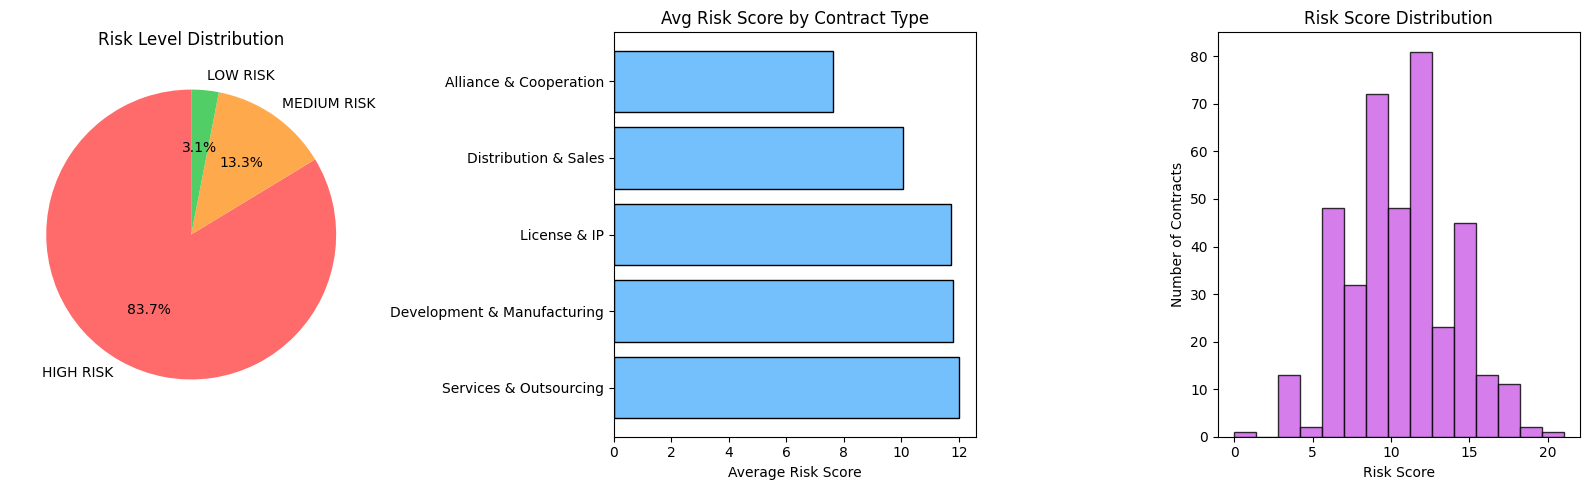

Charts saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Risk level pie chart
risk_counts = risk_df["risk_level"].value_counts()
colors = {"LOW RISK": "#51cf66",
          "MEDIUM RISK": "#ffa94d",
          "HIGH RISK": "#ff6b6b"}
pie_colors = [colors.get(l, "gray")
              for l in risk_counts.index]

axes[0].pie(risk_counts.values,
            labels=risk_counts.index,
            colors=pie_colors,
            autopct="%1.1f%%",
            startangle=90)
axes[0].set_title("Risk Level Distribution")

# Plot 2: Risk score by contract type
type_risk = risk_df.groupby(
    "contract_type"
)["risk_score"].mean().sort_values(ascending=False)

axes[1].barh(type_risk.index,
             type_risk.values,
             color="#74c0fc",
             edgecolor="black")
axes[1].set_title("Avg Risk Score by Contract Type")
axes[1].set_xlabel("Average Risk Score")

# Plot 3: Risk score distribution
axes[2].hist(risk_df["risk_score"],
             bins=15,
             color="#cc5de8",
             edgecolor="black",
             alpha=0.8)
axes[2].set_title("Risk Score Distribution")
axes[2].set_xlabel("Risk Score")
axes[2].set_ylabel("Number of Contracts")

plt.tight_layout()
plt.savefig("risk_assessment_charts.png", dpi=150)
plt.show()

print("Charts saved!")

In [ ]:
import pandas as pd
import json
import re

clauses_df  = pd.read_csv("extracted_clauses.csv")
df_original = pd.read_csv("contracts_relabeled.csv")

# ── Tightened risk flags ──────────────────────────────────────
RISK_FLAGS = {

    "unlimited_liability": {
        "severity": "HIGH",
        "description": "No liability cap — potential unlimited exposure",
        # More specific — must be near liability context
        "patterns": [
            r"liability\s+shall\s+(?:not\s+be\s+)?limited",
            r"unlimited\s+liability",
            r"no\s+(?:cap|limit)\s+on\s+(?:our\s+)?liability",
            r"liable\s+for\s+(?:any\s+and\s+)?all\s+damages"
            r"(?!\s+(?:except|excluding|other\s+than))"
        ]
    },

    "automatic_renewal": {
        "severity": "MEDIUM",
        "description": "Auto-renewal — contract renews without action",
        "patterns": [
            r"automatically?\s+(?:renew|be\s+renewed|extended)"
            r"(?!\s+(?:unless|except|if\s+notice))",
            r"auto[\-\s]?renew",
            r"deemed\s+(?:to\s+be\s+)?renewed"
        ]
    },

    "unilateral_termination": {
        "severity": "MEDIUM",
        "description": "One-sided termination rights detected",
        "patterns": [
            r"(?:company|licensor|provider|we)\s+may\s+terminate"
            r"[^\.]{0,60}without\s+(?:cause|notice|reason)",
            r"terminate\s+(?:this\s+agreement\s+)?at\s+"
            r"(?:its\s+)?(?:sole\s+)?(?:discretion|will)",
        ]
    },

    "broad_indemnification": {
        "severity": "HIGH",
        "description": "Broad indemnification obligation detected",
        "patterns": [
            # Must have indemnify + broad scope indicator
            r"indemnif[^\.]{0,100}"
            r"(?:any\s+and\s+all|unlimited|without\s+limit)"
            r"[^\.]{0,50}(?:claim|loss|damage|liabilit)",

            r"(?:defend|indemnify)\s+and\s+hold\s+harmless"
            r"[^\.]{0,150}third\s+part",
        ]
    },

    "ip_ownership_risk": {
        "severity": "HIGH",
        "description": "IP ownership fully assigned away",
        "patterns": [
            r"(?:all\s+)?(?:intellectual\s+property|ip)\s+"
            r"(?:rights?\s+)?(?:shall\s+)?(?:belong|vest|"
            r"be\s+owned\s+exclusively)\s+to\s+"
            r"(?:company|licensor|provider)",
            r"work\s+made\s+for\s+hire",
            r"hereby\s+assigns?\s+all\s+(?:right|title|interest)"
            r"[^\.]{0,60}intellectual\s+property"
        ]
    },

    "non_compete_risk": {
        "severity": "MEDIUM",
        "description": "Non-compete restriction found",
        "patterns": [
            r"(?:shall\s+not|will\s+not|must\s+not)\s+"
            r"(?:directly\s+or\s+indirectly\s+)?"
            r"(?:compete|engage\s+in\s+(?:any\s+)?competing)",
            r"non[\-\s]compete\s+(?:agreement|clause|provision|period)",
        ]
    },

    "confidentiality_risk": {
        "severity": "LOW",
        "description": "Perpetual confidentiality obligation",
        "patterns": [
            r"confidentialit[^\.]{0,80}"
            r"(?:perpetual|indefinite|no\s+time\s+limit)",
            r"confidentiality\s+obligations?\s+shall\s+survive"
            r"[^\.]{0,60}(?:indefinitely|perpetually|"
            r"without\s+limit)"
        ]
    },

    "dispute_resolution_missing": {
        "severity": "LOW",
        "description": "No dispute resolution mechanism found",
        "check_absence": True,
        "patterns": [
            r"arbitrat",
            r"mediat",
            r"dispute\s+resolution",
            r"\badr\b"
        ]
    }
}


CRITICAL_CLAUSES = {
    "Alliance & Cooperation": [
        "parties",
        "termination",
        "jurisdiction"
    ],
    "Distribution & Sales": [
        "parties",
        "termination",
        "jurisdiction"
    ],
    "License & IP": [
        "parties",
        "termination",
        "liability_limit",
        "jurisdiction"
    ],
    "Services & Outsourcing": [
        "parties",
        "termination",
        "liability_limit",
        "jurisdiction"
    ],
    "Development & Manufacturing": [
        "parties",
        "termination",
        "liability_limit",
        "jurisdiction"
    ]
}

print("Tightened risk rules loaded!")

Tightened risk rules loaded!


In [ ]:
def check_missing_clauses(row):
    contract_type = row["contract_type"]
    risks = []
    required = CRITICAL_CLAUSES.get(contract_type, [
        "parties", "termination", "jurisdiction"
    ])
    for clause in required:
        value = str(row.get(clause, "")).strip()
        if not value or value == "nan":
            risks.append({
                "type":        "missing_clause",
                "clause":      clause,
                "severity":    "HIGH",
                "description": f"Missing: {clause}"
            })
    return risks


def check_risk_flags(text):
    risks = []
    if not text:
        return risks

    for flag_name, flag_info in RISK_FLAGS.items():
        if flag_info.get("check_absence"):
            found = any(
                re.search(p, text, re.IGNORECASE)
                for p in flag_info["patterns"]
            )
            if not found:
                risks.append({
                    "type":        flag_name,
                    "severity":    flag_info["severity"],
                    "description": flag_info["description"]
                })
        else:
            for pattern in flag_info["patterns"]:
                match = re.search(
                    pattern, text, re.IGNORECASE | re.DOTALL
                )
                if match:
                    start   = max(0, match.start() - 30)
                    end     = min(len(text), match.end() + 60)
                    context = text[start:end].strip()
                    context = re.sub(r'\s+', ' ', context)
                    risks.append({
                        "type":        flag_name,
                        "severity":    flag_info["severity"],
                        "description": flag_info["description"],
                        "context":     context[:150]
                    })
                    break
    return risks


def calculate_risk_score(risks):
    severity_scores = {"HIGH": 3, "MEDIUM": 2, "LOW": 1}
    total = sum(
        severity_scores.get(r["severity"], 0) for r in risks
    )
    if total <= 2:
        return total, "LOW RISK",    "🟢"
    elif total <= 5:
        return total, "MEDIUM RISK", "🟡"
    else:
        return total, "HIGH RISK",   "🔴"


def assess_contract_risk(row, original_text=""):
    all_risks  = []
    all_risks += check_missing_clauses(row)
    if original_text:
        all_risks += check_risk_flags(original_text)

    score, level, emoji = calculate_risk_score(all_risks)

    return {
        "risk_score":   score,
        "risk_level":   level,
        "risk_emoji":   emoji,
        "risk_count":   len(all_risks),
        "high_risks":   sum(1 for r in all_risks
                           if r["severity"] == "HIGH"),
        "medium_risks": sum(1 for r in all_risks
                           if r["severity"] == "MEDIUM"),
        "low_risks":    sum(1 for r in all_risks
                           if r["severity"] == "LOW"),
        "risks":        all_risks
    }


#Test on 3 samples
print("Testing on 3 contracts:")
print("=" * 60)

for i in range(min(3, len(clauses_df))):
    row           = clauses_df.iloc[i]
    original_text = str(df_original.iloc[i].get("text", ""))

    assessment = assess_contract_risk(row, original_text)

    print(f"\nContract {i+1}: {row['contract_type']}")
    print("-" * 40)
    print(f"  {assessment['risk_emoji']} {assessment['risk_level']}"
          f" (Score: {assessment['risk_score']})")
    print(f"  Flags: {assessment['risk_count']} "
          f"(HIGH:{assessment['high_risks']} "
          f"MED:{assessment['medium_risks']} "
          f"LOW:{assessment['low_risks']})")

    for risk in assessment["risks"]:
        e = ("🔴" if risk["severity"] == "HIGH"
             else "🟡" if risk["severity"] == "MEDIUM"
             else "🟢")
        print(f"    {e} [{risk['severity']}] {risk['description']}")
        if "context" in risk:
            print(f"       ...{risk['context'][:80]}...")


# Run on all contracts
print("\n\nRunning on all 392 contracts...")
risk_results = []

for i, row in clauses_df.iterrows():
    original_text = ""
    matching = df_original[
        df_original["contract_id"] == row["contract_id"]
    ]
    if len(matching) > 0:
        original_text = str(matching.iloc[0].get("text", ""))

    assessment = assess_contract_risk(row, original_text)
    risk_results.append({
        "contract_id":   row["contract_id"],
        "contract_type": row["contract_type"],
        "risk_score":    assessment["risk_score"],
        "risk_level":    assessment["risk_level"],
        "high_risks":    assessment["high_risks"],
        "medium_risks":  assessment["medium_risks"],
        "low_risks":     assessment["low_risks"],
        "risk_count":    assessment["risk_count"],
        "risk_details":  json.dumps(assessment["risks"])
    })

risk_df = pd.DataFrame(risk_results)
risk_df.to_csv("risk_assessment.csv", index=False)

#Final statistics
print(f"\nRisk Assessment Statistics:")
print(f"{'='*50}")
print(f"  Total contracts: {len(risk_df)}")
print()

for level in ["LOW RISK", "MEDIUM RISK", "HIGH RISK"]:
    count = (risk_df["risk_level"] == level).sum()
    pct   = count / len(risk_df) * 100
    bar   = "█" * int(pct / 3)
    emoji = ("🟢" if "LOW" in level
             else "🟡" if "MEDIUM" in level
             else "🔴")
    print(f"  {emoji} {level:<12} {count:>3} ({pct:>5.1f}%) {bar}")

print()
print("  Risk Score by Contract Type:")
type_risks = risk_df.groupby(
    "contract_type"
)["risk_score"].mean().sort_values(ascending=False)

for ctype, score in type_risks.items():
    bar = "█" * int(score)
    print(f"    {ctype:<35} {score:.1f} {bar}")

print(f"\n  Mean risk score: {risk_df['risk_score'].mean():.2f}")
print(f"  Mean flag count: {risk_df['risk_count'].mean():.1f}")
print(f"\nSaved to risk_assessment.csv ✅")

Testing on 3 contracts:

Contract 1: Alliance & Cooperation
----------------------------------------
  🟡 MEDIUM RISK (Score: 3)
  Flags: 1 (HIGH:1 MED:0 LOW:0)
    🔴 [HIGH] Missing: termination

Contract 2: Alliance & Cooperation
----------------------------------------
  🟡 MEDIUM RISK (Score: 5)
  Flags: 2 (HIGH:1 MED:1 LOW:0)
    🔴 [HIGH] Missing: termination
    🟡 [MEDIUM] Auto-renewal — contract renews without action
       ...nt calendar year and shall be automatically renewed for successive one (1) year ...

Contract 3: Alliance & Cooperation
----------------------------------------
  🟡 MEDIUM RISK (Score: 3)
  Flags: 1 (HIGH:1 MED:0 LOW:0)
    🔴 [HIGH] Broad indemnification obligation detected
       ...bligations. NCM shall defend, indemnify and hold harmless Network Affiliate and ...


Running on all 392 contracts...

Risk Assessment Statistics:
  Total contracts: 392

  🟢 LOW RISK     102 ( 26.0%) ████████
  🟡 MEDIUM RISK  154 ( 39.3%) █████████████
  🔴 HIGH RISK    136 ( 34.

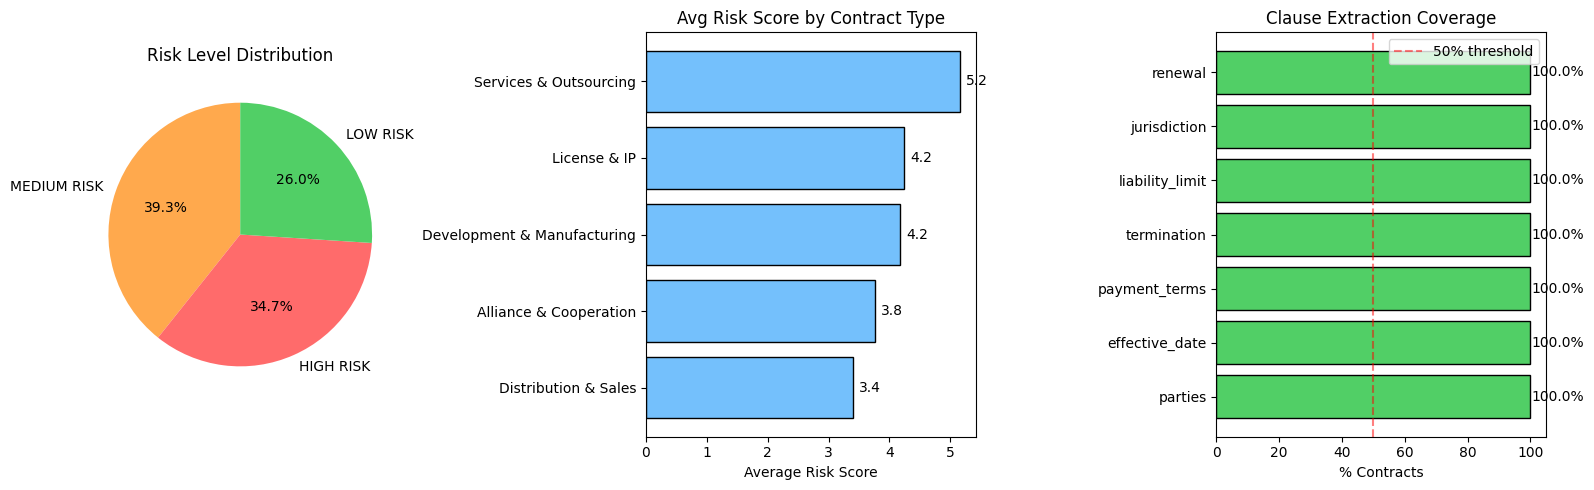

Charts saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

risk_df     = pd.read_csv("risk_assessment.csv")
clauses_df  = pd.read_csv("extracted_clauses.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Risk distribution pie
risk_counts = risk_df["risk_level"].value_counts()
colors = {
    "LOW RISK":    "#51cf66",
    "MEDIUM RISK": "#ffa94d",
    "HIGH RISK":   "#ff6b6b"
}
pie_colors = [colors.get(l, "gray") for l in risk_counts.index]

axes[0].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Risk Level Distribution")

# Plot 2: Risk score by contract type
type_risk = risk_df.groupby(
    "contract_type"
)["risk_score"].mean().sort_values(ascending=True)

bars = axes[1].barh(
    type_risk.index,
    type_risk.values,
    color="#74c0fc",
    edgecolor="black"
)
axes[1].set_title("Avg Risk Score by Contract Type")
axes[1].set_xlabel("Average Risk Score")
for bar, val in zip(bars, type_risk.values):
    axes[1].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}",
        va="center"
    )

# Plot 3: Clause extraction coverage
clause_cols = [
    "parties", "effective_date", "payment_terms",
    "termination", "liability_limit",
    "jurisdiction", "renewal"
]
coverage = []
for col in clause_cols:
    pct = clauses_df[col].apply(
        lambda x: x != ""
    ).mean() * 100
    coverage.append(pct)

bars2 = axes[2].barh(
    clause_cols, coverage,
    color=["#51cf66" if c >= 50 else "#ff6b6b"
           for c in coverage],
    edgecolor="black"
)
axes[2].set_title("Clause Extraction Coverage")
axes[2].set_xlabel("% Contracts")
axes[2].axvline(x=50, color="red",
                linestyle="--", alpha=0.5,
                label="50% threshold")
axes[2].legend()
for bar, val in zip(bars2, coverage):
    axes[2].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig("final_analysis_charts.png", dpi=150)
plt.show()
print("Charts saved!")

In [ ]:
!zip legal_word2vec.zip legal_word2vec.model
from google.colab import files
files.download("legal_word2vec.zip")

  adding: legal_word2vec.model (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>